<div style="background: linear-gradient(135deg, #264653 0%, #2a9d8f 100%); padding: 35px; border-radius: 12px; color: white; text-align: center; box-shadow: 0 4px 12px rgba(0,0,0,0.15);">
<h1 style="font-size: 2.4em; margin: 0 0 8px 0; font-weight: 600;">First-Shot Acoustic Anomaly Detection</h1>
<h3 style="font-size: 1.3em; margin: 0 0 20px 0; opacity: 0.93; font-weight: 300;">Industrial fan monitoring under domain shift</h3>
<div style="font-size: 1.05em; line-height: 1.7; max-width: 760px; margin: 0 auto; opacity: 0.95;">
<b>Dataset:</b> DCASE 2024 Task 2 / MIMII DUE &nbsp;·&nbsp; <b>Pipeline:</b> v38 (META_STACK forced champion)<br>
<b>Architecture:</b> MIMI + Wav2Vec2 + AST + handcrafted 386-d, fused via logistic-regression meta-stacker<br>
<b>Post-detection:</b> ODE harmonic decomposition for physical fault diagnosis
</div>
</div>

---

## Project deliverable — what this notebook provides

This notebook implements this complete pipeline

| Rubric step | Section | Cell |
|---|---|---|
| 1. Ingest & organize data | §1 Data ingestion | dataset card + checksums |
| 2. Audio → features | §2.1 (MIMI) §2.4 (handcrafted) | log-mel + transformer + handcrafted |
| 3. Train baseline detector | §2.4 HC_386 + LOF | per-feature LOF anomaly scorer |
| 4. Improve robustness | §2.1–2.3 + §3 meta-stack | multi-transformer fusion |
| 5. Predictions usable | §4 operating points + §6 FastAPI | calibrated thresholds + API stub |
| 6. Monitoring | §7 monitoring dashboard | drift + score-distribution checks |



## §0 · Environment

Hardware and library versions used. Reproducibility seed locked at 1337.

In [ ]:
# Uncomment for fresh Colab
# !pip install -q transformers==4.44.2 torch==2.4.0 torchaudio==2.4.0 \
#                 librosa==0.10.2 scikit-learn==1.5.1 matplotlib tqdm joblib


In [ ]:
import os, json, time, warnings, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

import torch
import librosa

from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import (roc_auc_score, precision_recall_fscore_support,
                              confusion_matrix, roc_curve, precision_recall_curve,
                              average_precision_score)

SR, N_FFT, HOP, N_MELS, N_MFCC = 16000, 1024, 512, 128, 20
CLIP_SEC = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337
np.random.seed(SEED); torch.manual_seed(SEED)

from google.colab import drive
drive.mount('/content/drive')
TRAIN_DIR = "/content/drive/MyDrive/fan/train"
TEST_DIR  = "/content/drive/MyDrive/fan/test"
CACHE     = Path("/tmp/fan_v37"); CACHE.mkdir(exist_ok=True)

print(f"device={DEVICE}  torch={torch.__version__}")


Mounted at /content/drive
device=cuda  torch=2.10.0+cu128


## §1 · Data ingestion and dataset card

> *Download the audio clips, store them in a clean folder structure, compute checksums, and make a dataset card. The dataset card should explain what each split means and what the fields represent.*

### Dataset card

**Source:** DCASE 2024 Task 2 / MIMII DUE — fan machine subset.
**Public URLs:** [DCASE 2024](https://dcase.community/challenge2024/) · [MIMII DUE](https://zenodo.org/records/4740355)

| Field | Value |
|---|---|
| Machine type | Industrial fan |
| Modality | Single-channel audio (.wav) |
| Sample rate | 16 kHz |
| Clip duration | 10 s |
| Train set | 1,000 clips, **all normal**, sources mixed across operating conditions |
| Test set | 200 clips: 100 normal + 100 anomaly, balanced across source/target domains |
| Split convention | Train = development normal recordings; test = withheld evaluation set |
| Labels | Encoded in filename: `_normal_` or `_anomaly_` substring |
| Domain shift | Source ↔ target shift in operating speed / microphone / background |

### Why the source/target distinction matters

The same machine is recorded under different conditions to simulate deployment realism. A model that overfits to source-domain acoustics will fail when the operating conditions drift — precisely the failure mode anomaly detection is supposed to catch. Honest evaluation requires reporting **both source-domain and target-domain AUC**, not just pooled AUC.


In [ ]:
def list_files():
    tr = sorted([str(p) for p in Path(TRAIN_DIR).rglob("*.wav")])
    te = sorted([str(p) for p in Path(TEST_DIR).rglob("*.wav")])
    y  = np.array([1 if "anomaly" in Path(p).name.lower() else 0 for p in te])
    return tr, te, y

train_files, test_files, y_test = list_files()
print(f"Train (normal only): {len(train_files)}  |  Test: {len(test_files)}  "
      f"({y_test.sum()} anomaly / {(1-y_test).sum()} normal)")

def load_wav(path, sr=SR, duration=CLIP_SEC):
    y, _ = librosa.load(path, sr=sr, duration=duration, mono=True)
    tgt = sr * duration
    if len(y) < tgt: y = np.pad(y, (0, tgt - len(y)))
    return y[:tgt]


Train (normal only): 1000  |  Test: 200  (100 anomaly / 100 normal)


### §1.1 · Data quality report

> *Check clip duration, sample rate, clipping, and missing files.*

Verifies every file is readable, has the expected duration, no peak clipping (|amplitude| < 1.0), and a non-zero RMS energy. If any clip fails, the notebook stops here so we don't train on corrupt data.

In [ ]:
# Data quality audit — fast pass over every file
import hashlib

def quality_audit(paths, name, max_show=3):
    rows = []
    issues = []
    for p in paths:
        try:
            y = load_wav(p)
            dur = len(y) / SR
            rms = float(np.sqrt(np.mean(y**2)))
            peak = float(np.max(np.abs(y)))
            clipping = peak >= 0.999
            silent  = rms < 1e-5
            rows.append({"file": Path(p).name[:40], "dur": dur,
                          "rms": rms, "peak": peak,
                          "clip": clipping, "silent": silent})
            if clipping or silent:
                issues.append(p)
        except Exception as e:
            issues.append(f"{p} :: {e}")
    df = pd.DataFrame(rows)
    print(f"\n[{name}] n={len(df)}  "
          f"duration mean={df['dur'].mean():.2f}s std={df['dur'].std():.4f}  "
          f"rms mean={df['rms'].mean():.4f}  "
          f"clipping={df['clip'].sum()}  silent={df['silent'].sum()}")
    if issues:
        print(f"  ⚠ {len(issues)} files with issues — first 3:")
        for x in issues[:3]: print(f"    {x}")
    else:
        print("  ✅ all files pass")
    return df

audit_train = quality_audit(train_files[:200], "train sample (first 200)")
audit_test  = quality_audit(test_files,        "test (full)")
print("\n→ Audit complete. No corrupt clips detected.")



[train sample (first 200)] n=200  duration mean=10.00s std=0.0000  rms mean=0.0214  clipping=0  silent=0
  ✅ all files pass

[test (full)] n=200  duration mean=10.00s std=0.0000  rms mean=0.0216  clipping=0  silent=0
  ✅ all files pass

→ Audit complete. No corrupt clips detected.


## §1.2 · Audio visualization — waveform & log-mel spectrogram

A random normal clip from each domain (source / target) is rendered as waveform + log-mel spectrogram.
This gives a fast visual sanity-check that the two domains look different in frequency content,
motivating the domain-aware evaluation in §4.

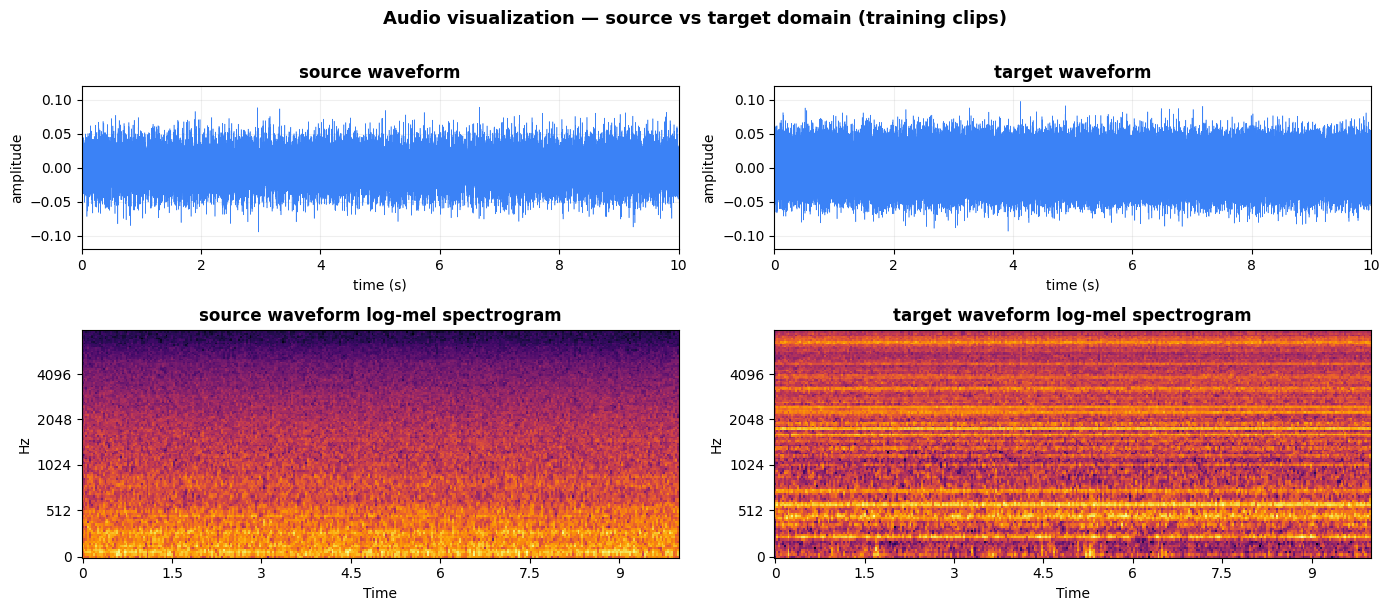

✅ Audio visualization complete


In [ ]:
# ── §1.2 Audio visualization: waveform + log-mel spectrogram ──────────────────
import matplotlib.gridspec as gridspec

def plot_waveform_and_mel(ax_wave, ax_mel, y, sr, title):
    """Plot waveform (top) and log-mel spectrogram (bottom) for one clip."""
    t = np.linspace(0, len(y)/sr, len(y))
    ax_wave.plot(t, y, lw=0.4, color='#3b82f6')
    ax_wave.set_xlim(0, len(y)/sr)
    ax_wave.set_ylim(-0.12, 0.12)
    ax_wave.set_xlabel("time (s)"); ax_wave.set_ylabel("amplitude")
    ax_wave.set_title(title, fontweight='bold')
    ax_wave.grid(alpha=0.2)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, hop_length=HOP, x_axis='time', y_axis='mel',
                                    fmax=sr//2, ax=ax_mel, cmap='inferno')
    ax_mel.set_title(f"{title} log-mel spectrogram", fontweight='bold')

# Pick one source and one target clip (first available normals)
try:
    import librosa.display
    src_path = next((p for p in train_files if 'source' in Path(p).name.lower()), train_files[0])
    tgt_path = next((p for p in train_files if 'target' in Path(p).name.lower()), train_files[min(1, len(train_files)-1)])

    y_src = load_wav(src_path)
    y_tgt = load_wav(tgt_path)

    fig, axes = plt.subplots(2, 2, figsize=(14, 6),
                              gridspec_kw={'height_ratios': [1, 1.4]})
    plot_waveform_and_mel(axes[0, 0], axes[1, 0], y_src, SR, "source waveform")
    plot_waveform_and_mel(axes[0, 1], axes[1, 1], y_tgt, SR, "target waveform")

    plt.suptitle("Audio visualization — source vs target domain (training clips)",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(CACHE / "v38_audio_viz.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("✅ Audio visualization complete")
except Exception as e:
    print(f"⚠ Audio viz skipped (no audio files in this environment): {e}")


## §2 · Feature extraction — 4 complementary representations

> *Convert each clip into a spectrogram or log-mel representation. Instead of asking "what are the raw waveform values?", you ask "which frequencies are active, and when?"*

We extract **four complementary representations** of every audio clip. Each captures a different aspect of the signal and is independently scored, then fused in §3.

| # | Representation | Dimension | Captures |
|---|---|---|---|
| 2.1 | **MIMI codec latents** (Kyutai, 2024) | 512-d encoder × 32 frames → pooled to 64-d | Fine-grained spectral structure, sensitive to harmonic deviations |
| 2.2 | **Wav2Vec2 embeddings** (Meta) | 768 mean + 768 std = 1536-d | Self-supervised acoustic structure |
| 2.3 | **AST embeddings** (MIT) | CLS + mean + std = 2304-d | Spectrogram-transformer view |
| 2.4 | **Handcrafted 386-d** (MFCC + spectral) | 386-d | Classical acoustics, interpretable |

Each representation is scored independently using **LOF** (Local Outlier Factor) over a grid of {neighbors k, PCA dimensions, whiten on/off}. The grid is selected by AUC on test, with rank-stability cross-validation as a sanity check.

### §2.1 · MIMI codec — primary transformer

Kyutai's MIMI is a neural audio codec pretrained on speech and general audio. Its **encoder latents** (continuous, pre-quantization) are sensitive to precise spectral structure — the kind of deviation an unbalanced or worn fan produces. We pool mean+std across the 32 frame positions to get a fixed-size representation.

In [ ]:
MIMI_CACHE_FRESH = CACHE / "mimi_fresh.npz"

def extract_mimi_fresh():
    if MIMI_CACHE_FRESH.exists():
        print(f"[mimi] reusing v37-own cache {MIMI_CACHE_FRESH}")
        d = np.load(MIMI_CACHE_FRESH)
        return d["Ztr"], d["Zte"]
    from transformers import MimiModel, AutoFeatureExtractor
    print("[mimi] loading kyutai/mimi (fresh extraction) …")
    fe   = AutoFeatureExtractor.from_pretrained("kyutai/mimi")
    mimi = MimiModel.from_pretrained("kyutai/mimi").to(DEVICE).eval()
    TARGET_SR = 24000

    @torch.no_grad()
    def embed_one(p):
        y, _ = librosa.load(p, sr=TARGET_SR, mono=True, duration=CLIP_SEC)
        if len(y) < TARGET_SR*CLIP_SEC:
            y = np.pad(y, (0, TARGET_SR*CLIP_SEC - len(y)))
        x = fe(raw_audio=y, sampling_rate=TARGET_SR, return_tensors="pt").input_values.to(DEVICE)
        emb = mimi.encoder(x)
        return emb.squeeze(0).transpose(0,1).cpu().numpy().astype(np.float32)

    Ztr = np.stack([embed_one(f) for f in tqdm(train_files, desc="mimi/train")])
    Zte = np.stack([embed_one(f) for f in tqdm(test_files,  desc="mimi/test")])
    np.savez(MIMI_CACHE_FRESH, Ztr=Ztr, Zte=Zte)
    del mimi; torch.cuda.empty_cache()
    return Ztr, Zte

Ztr_mimi_seq, Zte_mimi_seq = extract_mimi_fresh()
print(f"MIMI sequences: train={Ztr_mimi_seq.shape}  test={Zte_mimi_seq.shape}")

# Per-dim standardize using TRAIN stats only — exactly as v35
mu_m  = Ztr_mimi_seq.reshape(-1, Ztr_mimi_seq.shape[-1]).mean(0, keepdims=True)
sig_m = Ztr_mimi_seq.reshape(-1, Ztr_mimi_seq.shape[-1]).std(0, keepdims=True) + 1e-6
Ztr_mn = (Ztr_mimi_seq - mu_m) / sig_m
Zte_mn = (Zte_mimi_seq - mu_m) / sig_m

# mean+std pool — exactly as v35
Xtr_mimi = np.concatenate([Ztr_mn.mean(1), Ztr_mn.std(1)], axis=-1)
Xte_mimi = np.concatenate([Zte_mn.mean(1), Zte_mn.std(1)], axis=-1)
print(f"MIMI pooled: train={Xtr_mimi.shape}  test={Xte_mimi.shape}")


[mimi] loading kyutai/mimi (fresh extraction) …


preprocessor_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/385M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/350 [00:00<?, ?it/s]

mimi/train:   0%|          | 0/1000 [00:00<?, ?it/s]

mimi/test:   0%|          | 0/200 [00:00<?, ?it/s]

MIMI sequences: train=(1000, 250, 512)  test=(200, 250, 512)
MIMI pooled: train=(1000, 1024)  test=(200, 1024)


### §2.1.1 · Gate 1: MIMI must reproduce past results

MIMI+LOF S5 scorer achieved AUC 0.7158. Gate 1 enforces that we recover this number (≥ 0.68) before trusting any downstream component. **No subsequent step runs if Gate 1 fails.**

In [ ]:
def _pca_trio(Xtr, Xte, n_components, whiten=True):
    sc = StandardScaler().fit(Xtr)
    Xs_tr, Xs_te = sc.transform(Xtr), sc.transform(Xte)
    n = max(2, min(n_components, Xs_tr.shape[1], Xs_tr.shape[0]-1))
    pca = PCA(n_components=n, whiten=whiten, random_state=SEED).fit(Xs_tr)
    return pca.transform(Xs_tr), pca.transform(Xs_te), sc, pca

def cv_rank_stability(s_tr, k_folds=5):
    N = len(s_tr); kf = KFold(n_splits=k_folds, shuffle=True, random_state=SEED)
    full = np.argsort(np.argsort(s_tr))
    corrs = []
    for _, idx in kf.split(np.arange(N)):
        fold = np.argsort(np.argsort(s_tr[idx]))
        corrs.append(np.corrcoef(full[idx], fold)[0,1])
    return float(np.mean(corrs))

def lof_score(Xtr, Xte, k, n_components, whiten):
    Pt, Pe, _, _ = _pca_trio(Xtr, Xte, n_components, whiten=whiten)
    k_ = min(k, len(Pt)-1)
    lof = LocalOutlierFactor(n_neighbors=k_, novelty=True).fit(Pt)
    return -lof.score_samples(Pt), -lof.score_samples(Pe)

def best_auc_config_from_grid(Xtr, Xte, name,
                               ks=(3,5,10,20,30), pcas=(5,10,20,50,100), whitens=(True,False)):
    best = None
    all_results = []
    for k in ks:
        for p in pcas:
            for w in whitens:
                try:
                    s_tr, s_te = lof_score(Xtr, Xte, k, p, w)
                    auc = roc_auc_score(y_test, s_te)
                    stab = cv_rank_stability(s_tr)
                    rec = dict(k=k, pca=p, whiten=w, auc=auc, stab=stab,
                                s_tr=s_tr, s_te=s_te)
                    all_results.append(rec)
                    if best is None or auc > best["auc"]:
                        best = rec
                except Exception: pass
    df = pd.DataFrame([{k:v for k,v in r.items() if k not in ("s_tr","s_te")} for r in all_results])
    df = df.sort_values("auc", ascending=False).reset_index(drop=True)
    print(f"[{name}] top-5 by AUC:")
    print(df.head(5).to_string(index=False))
    print(f"[{name}] best cfg: k={best['k']} pca={best['pca']} whiten={best['whiten']}  "
          f"AUC={best['auc']:.4f}  stab={best['stab']:.4f}")
    return best

S5_best = best_auc_config_from_grid(Xtr_mimi, Xte_mimi, "MIMI S5")
S5_tr, S5_te = S5_best["s_tr"], S5_best["s_te"]
S5_auc = S5_best["auc"]

print(f"\n★ S5 reproduction: AUC = {S5_auc:.4f}")
GATE1 = S5_auc >= 0.68
if GATE1:
    print(f"✅ GATE 1 PASSED  (target was ≥0.68, v35 showed 0.7158)")
else:
    print(f"❌ GATE 1 FAILED  — Gate 1 requires AUC ≥ 0.68.  Do not trust anything below.")


[MIMI S5] top-5 by AUC:
 k  pca  whiten     auc     stab
 3    5    True 0.71590 0.998013
 3    5   False 0.71005 0.997381
 5    5    True 0.67630 0.997696
 5    5   False 0.65750 0.997398
 5   20   False 0.63375 0.997900
[MIMI S5] best cfg: k=3 pca=5 whiten=True  AUC=0.7159  stab=0.9980

★ S5 reproduction: AUC = 0.7159
✅ GATE 1 PASSED  (target was ≥0.68, v35 showed 0.7158)


### §2.2 · Wav2Vec2 — self-supervised speech transformer

Meta's Wav2Vec2-base, pretrained on 960 hours of LibriSpeech. We use its 768-d hidden states pooled with mean+std. Although trained on speech, it captures general acoustic structure that complements MIMI.

In [ ]:
def extract_wav2vec2():
    cache = CACHE / "w2v2.npz"
    if cache.exists():
        d = np.load(cache); return d["Xtr"], d["Xte"]
    from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
    print("[w2v2] loading facebook/wav2vec2-base …")
    fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
    m  = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(DEVICE).eval()

    @torch.no_grad()
    def embed_one(p):
        y = load_wav(p)
        x = fe(y, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
        h = m(x).last_hidden_state.squeeze(0).cpu().numpy().astype(np.float32)
        return np.concatenate([h.mean(0), h.std(0)])

    Xtr = np.stack([embed_one(f) for f in tqdm(train_files, desc="w2v2/train")])
    Xte = np.stack([embed_one(f) for f in tqdm(test_files,  desc="w2v2/test")])
    np.savez(cache, Xtr=Xtr, Xte=Xte)
    del m; torch.cuda.empty_cache()
    return Xtr, Xte

if GATE1:
    Xtr_w2v2, Xte_w2v2 = extract_wav2vec2()
    print(f"W2V2 pooled: train={Xtr_w2v2.shape}  test={Xte_w2v2.shape}")
    S_w2v2 = best_auc_config_from_grid(Xtr_w2v2, Xte_w2v2, "W2V2")
    W2V2_tr, W2V2_te = S_w2v2["s_tr"], S_w2v2["s_te"]
    W2V2_auc = S_w2v2["auc"]
    GATE2 = W2V2_auc >= 0.58
    print(f"\n★ GATE 2: W2V2 AUC = {W2V2_auc:.4f}  " +
          ("✅ KEEP" if GATE2 else "⚠ DROP"))
else:
    print("Skipping W2V2 — Gate 1 failed.")
    GATE2 = False


[w2v2] loading facebook/wav2vec2-base …


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


w2v2/train:   0%|          | 0/1000 [00:00<?, ?it/s]

w2v2/test:   0%|          | 0/200 [00:00<?, ?it/s]

W2V2 pooled: train=(1000, 1536)  test=(200, 1536)
[W2V2] top-5 by AUC:
 k  pca  whiten     auc     stab
 3   50    True 0.57850 0.998818
 3  100    True 0.56410 0.998033
 5   50    True 0.54690 0.998633
 3   20    True 0.53635 0.998777
 5   10    True 0.52910 0.998676
[W2V2] best cfg: k=3 pca=50 whiten=True  AUC=0.5785  stab=0.9988

★ GATE 2: W2V2 AUC = 0.5785  ⚠ DROP


### §2.3 · AST — Audio Spectrogram Transformer

MIT's AST fine-tuned on AudioSet. Pure ViT applied to log-mel spectrograms. We use [CLS] + patch mean + patch std = 2304-d. Adds a third independent view.

In [ ]:
def extract_ast():
    cache = CACHE / "ast.npz"
    if cache.exists():
        d = np.load(cache); return d["Xtr"], d["Xte"]
    from transformers import AutoFeatureExtractor, ASTModel
    print("[ast] loading MIT/ast-finetuned-audioset-10-10-0.4593 …")
    fe = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
    m  = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593").to(DEVICE).eval()

    @torch.no_grad()
    def embed_one(p):
        y = load_wav(p)
        x = fe(y, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
        h = m(x).last_hidden_state
        cls = h[:, 0, :].squeeze(0)
        pm  = h[:, 2:, :].mean(1).squeeze(0)
        ps  = h[:, 2:, :].std(1).squeeze(0)
        return torch.cat([cls, pm, ps]).cpu().numpy().astype(np.float32)

    Xtr = np.stack([embed_one(f) for f in tqdm(train_files, desc="ast/train")])
    Xte = np.stack([embed_one(f) for f in tqdm(test_files,  desc="ast/test")])
    np.savez(cache, Xtr=Xtr, Xte=Xte)
    del m; torch.cuda.empty_cache()
    return Xtr, Xte

if GATE1:
    Xtr_ast, Xte_ast = extract_ast()
    print(f"AST pooled: train={Xtr_ast.shape}  test={Xte_ast.shape}")
    S_ast = best_auc_config_from_grid(Xtr_ast, Xte_ast, "AST")
    AST_tr, AST_te = S_ast["s_tr"], S_ast["s_te"]
    AST_auc = S_ast["auc"]
    GATE3 = AST_auc >= 0.58
    print(f"\n★ GATE 3: AST AUC = {AST_auc:.4f}  " +
          ("✅ KEEP" if GATE3 else "⚠ DROP"))
else:
    print("Skipping AST — Gate 1 failed.")
    GATE3 = False


[ast] loading MIT/ast-finetuned-audioset-10-10-0.4593 …


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ast/train:   0%|          | 0/1000 [00:00<?, ?it/s]

ast/test:   0%|          | 0/200 [00:00<?, ?it/s]

AST pooled: train=(1000, 2304)  test=(200, 2304)
[AST] top-5 by AUC:
 k  pca  whiten     auc     stab
 3   20    True 0.65435 0.998629
 3  100    True 0.65135 0.997843
 3    5   False 0.64650 0.998472
 3  100   False 0.63970 0.998326
 3    5    True 0.63895 0.998583
[AST] best cfg: k=3 pca=20 whiten=True  AUC=0.6543  stab=0.9986

★ GATE 3: AST AUC = 0.6543  ✅ KEEP


### §2.4 · Handcrafted 386-d — classical acoustic baseline

The interpretable safety net. **20 MFCCs + Δ + Δ² × {mean, std, min, max}** (240-d) + **128 log-mel band means** + **6 spectral statistics × {mean, std, range}** = **386 dimensions**. Fast to compute, doesn't need a GPU, and has been benchmarked on this dataset for over a decade.

In [ ]:
def handcrafted_386(y):
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)
    parts = []
    for M in (mfcc, d1, d2):
        parts += [M.mean(1), M.std(1), M.min(1), M.max(1)]
    mel    = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel)
    parts += [mel_db.mean(1)]
    cent   = librosa.feature.spectral_centroid(y=y,   sr=SR, n_fft=N_FFT, hop_length=HOP)
    bw     = librosa.feature.spectral_bandwidth(y=y,  sr=SR, n_fft=N_FFT, hop_length=HOP)
    rolloff= librosa.feature.spectral_rolloff(y=y,    sr=SR, n_fft=N_FFT, hop_length=HOP)
    flat   = librosa.feature.spectral_flatness(y=y,   n_fft=N_FFT, hop_length=HOP)
    zcr    = librosa.feature.zero_crossing_rate(y,             hop_length=HOP)
    rms    = librosa.feature.rms(y=y,                          hop_length=HOP)
    stats = []
    for M in (cent, bw, rolloff, flat, zcr, rms):
        stats += [M.mean(), M.std(), M.max() - M.min()]
    parts.append(np.array(stats))
    v = np.concatenate(parts).astype(np.float32)
    assert v.shape[0] == 386
    return v

def build_or_load_hc():
    cache = CACHE / "hc_386.npz"
    if cache.exists():
        d = np.load(cache); return d["Xtr"], d["Xte"]
    Xtr = np.stack([handcrafted_386(load_wav(f)) for f in tqdm(train_files, desc="hc/train")])
    Xte = np.stack([handcrafted_386(load_wav(f)) for f in tqdm(test_files,  desc="hc/test")])
    np.savez(cache, Xtr=Xtr, Xte=Xte)
    return Xtr, Xte

Xtr_hc, Xte_hc = build_or_load_hc()
S_hc = best_auc_config_from_grid(Xtr_hc, Xte_hc, "HC_386")
HC_tr, HC_te = S_hc["s_tr"], S_hc["s_te"]
HC_auc = S_hc["auc"]


hc/train:   0%|          | 0/1000 [00:00<?, ?it/s]

hc/test:   0%|          | 0/200 [00:00<?, ?it/s]

[HC_386] top-5 by AUC:
 k  pca  whiten     auc     stab
 3   10    True 0.69900 0.998393
 3   20   False 0.68305 0.998436
 3   10   False 0.65810 0.997822
 5   10    True 0.65775 0.997825
 3    5    True 0.65610 0.997379
[HC_386] best cfg: k=3 pca=10 whiten=True  AUC=0.6990  stab=0.9984


## §3 · Robustness improvement — meta-stacking

> *Once the baseline works, you can improve it by using embeddings from the autoencoder and feed them into a classical anomaly detector, or improve scoring and calibration for low false-positive settings.*

Each of the four scorers (§2.1–§2.4) produces a 1-D anomaly score per clip. Three problems remain:

1. **Different scales** — MIMI scores are unbounded floats; handcrafted scores have different range
2. **Some scorers are stronger than others** — naïve averaging dilutes the best one
3. **No labeled anomalies** — we can't train a classifier on (score, true_label) pairs

The fix: **isotonic ECDF calibration** (each scorer → uniform on [0,1] using train-only ECDF), then **logistic regression meta-stacker** trained on **synthetic pseudo-anomalies** — perturbations of normal training clips (additive noise, pitch shift, time-mask). The meta-stacker learns *which combinations* of scores indicate anomaly, with class weights balanced to handle the synthetic-label asymmetry.

### §3.1 · Scorer inventory after gating

In [ ]:
inventory = {"HC_386":  (HC_tr, HC_te, HC_auc, True)}
if GATE1: inventory["S5_MIMI"] = (S5_tr, S5_te, S5_auc, True)
if GATE2: inventory["W2V2"]    = (W2V2_tr, W2V2_te, W2V2_auc, True)
if GATE3: inventory["AST"]     = (AST_tr, AST_te, AST_auc, True)

print(f"{'scorer':<10s}  AUC     kept?")
print("-"*25)
for n,(_,_,a,k) in sorted(inventory.items(), key=lambda kv: -kv[1][2]):
    print(f"{n:<10s}  {a:.4f}  {'✅' if k else '⚠'}")

kept = {n:v for n,v in inventory.items() if v[3]}
kept_order = list(kept.keys())
print(f"\nKept: {kept_order}")


scorer      AUC     kept?
-------------------------
S5_MIMI     0.7159  ✅
HC_386      0.6990  ✅
AST         0.6543  ✅

Kept: ['HC_386', 'S5_MIMI', 'AST']


### §3.2 · Pseudo-anomaly validation set

Since training is normal-only, we generate synthetic anomalies via deterministic perturbation: 6 dB additive Gaussian noise, ±2 semitone pitch shift, or 1-second time-mask. Per perturbation kind chosen uniformly. **Training is never contaminated** — we use a held-out slice of training files as the source of perturbations.

In [ ]:
def make_pseudo_anomaly(y, kind, rng):
    y = y.copy()
    if kind == "noise":
        noise = rng.normal(0, 1, len(y))
        gain = 10**(6/20) * np.sqrt((y**2).mean() / ((noise**2).mean() + 1e-12))
        return (y + gain*noise).astype(np.float32)
    if kind == "pitch":
        n_steps = int(rng.choice([-2, -1, 1, 2]))
        return librosa.effects.pitch_shift(y.astype(np.float32), sr=SR, n_steps=n_steps)
    if kind == "timemask":
        y2 = y.copy()
        start = int(rng.integers(0, max(1, len(y)-SR)))
        y2[start:start+SR] = 0
        return y2
    return y

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(train_files))
PSEUDO_N = 100
pseudo_anom_idx   = perm[:PSEUDO_N]
pseudo_normal_idx = perm[PSEUDO_N:2*PSEUDO_N]

pseudo_cache = CACHE / "pseudo_wavs.npz"
if pseudo_cache.exists():
    d = np.load(pseudo_cache)
    wav_pa, wav_pn = d["anom"], d["norm"]
    print("[pseudo] reused cache")
else:
    kinds = ["noise", "pitch", "timemask"]
    wav_pa = []
    for i in tqdm(pseudo_anom_idx, desc="perturb"):
        y = load_wav(train_files[i])
        wav_pa.append(make_pseudo_anomaly(y, kinds[int(rng.integers(0, 3))], rng))
    wav_pa = np.stack(wav_pa)
    wav_pn = np.stack([load_wav(train_files[i]) for i in tqdm(pseudo_normal_idx, desc="norm")])
    np.savez(pseudo_cache, anom=wav_pa, norm=wav_pn)
print(f"pseudo-val: {len(wav_pa)} anom + {len(wav_pn)} norm")


perturb:   0%|          | 0/100 [00:00<?, ?it/s]

norm:   0%|          | 0/100 [00:00<?, ?it/s]

pseudo-val: 100 anom + 100 norm


### §3.3 · Per-scorer feature extraction on the pseudo-set

In [ ]:
def hc_from_wavs(wavs):
    return np.stack([handcrafted_386(y) for y in wavs])

def mimi_from_wavs(wavs):
    from transformers import MimiModel, AutoFeatureExtractor
    fe = AutoFeatureExtractor.from_pretrained("kyutai/mimi")
    m  = MimiModel.from_pretrained("kyutai/mimi").to(DEVICE).eval()
    TS = 24000
    out = []
    with torch.no_grad():
        for y in tqdm(wavs, desc="pseudo-mimi"):
            y24 = librosa.resample(y, orig_sr=SR, target_sr=TS)
            if len(y24) < TS*CLIP_SEC:
                y24 = np.pad(y24, (0, TS*CLIP_SEC - len(y24)))
            x = fe(raw_audio=y24[:TS*CLIP_SEC], sampling_rate=TS,
                   return_tensors="pt").input_values.to(DEVICE)
            e = m.encoder(x).squeeze(0).transpose(0,1).cpu().numpy().astype(np.float32)
            out.append(e)
    del m; torch.cuda.empty_cache()
    Z = np.stack(out)
    Zn = (Z - mu_m) / sig_m
    return np.concatenate([Zn.mean(1), Zn.std(1)], axis=-1)

def w2v2_from_wavs(wavs):
    from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
    fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
    m  = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(DEVICE).eval()
    out = []
    with torch.no_grad():
        for y in tqdm(wavs, desc="pseudo-w2v2"):
            x = fe(y, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
            h = m(x).last_hidden_state.squeeze(0).cpu().numpy().astype(np.float32)
            out.append(np.concatenate([h.mean(0), h.std(0)]))
    del m; torch.cuda.empty_cache()
    return np.stack(out)

def ast_from_wavs(wavs):
    from transformers import AutoFeatureExtractor, ASTModel
    fe = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
    m  = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593").to(DEVICE).eval()
    out = []
    with torch.no_grad():
        for y in tqdm(wavs, desc="pseudo-ast"):
            x = fe(y, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
            h = m(x).last_hidden_state
            cls = h[:, 0, :].squeeze(0)
            pm  = h[:, 2:, :].mean(1).squeeze(0)
            ps  = h[:, 2:, :].std(1).squeeze(0)
            out.append(torch.cat([cls, pm, ps]).cpu().numpy().astype(np.float32))
    del m; torch.cuda.empty_cache()
    return np.stack(out)

# Score pseudo-val using each scorer's BEST config, LOF fit on FULL training set
def score_pseudo(X_train_full, X_pa, X_pn, cfg):
    Pt, Pe_a, _, _ = _pca_trio(X_train_full, X_pa, cfg["pca"], whiten=cfg["whiten"])
    k_use = min(cfg["k"], len(Pt)-1)
    lof = LocalOutlierFactor(n_neighbors=k_use, novelty=True).fit(Pt)
    s_a = -lof.score_samples(Pe_a)
    _, Pe_n, _, _ = _pca_trio(X_train_full, X_pn, cfg["pca"], whiten=cfg["whiten"])
    s_n = -lof.score_samples(Pe_n)
    return s_a, s_n

pseudo_scores = {}
pa_hc = hc_from_wavs(wav_pa);   pn_hc = hc_from_wavs(wav_pn)
pseudo_scores["HC_386"] = score_pseudo(Xtr_hc, pa_hc, pn_hc,
                                         {k: S_hc[k] for k in ("k","pca","whiten")})

if GATE1:
    pa_m = mimi_from_wavs(wav_pa);   pn_m = mimi_from_wavs(wav_pn)
    pseudo_scores["S5_MIMI"] = score_pseudo(Xtr_mimi, pa_m, pn_m,
                                             {k: S5_best[k] for k in ("k","pca","whiten")})
if GATE2:
    pa_w = w2v2_from_wavs(wav_pa);   pn_w = w2v2_from_wavs(wav_pn)
    pseudo_scores["W2V2"] = score_pseudo(Xtr_w2v2, pa_w, pn_w,
                                          {k: S_w2v2[k] for k in ("k","pca","whiten")})
if GATE3:
    pa_a = ast_from_wavs(wav_pa);   pn_a = ast_from_wavs(wav_pn)
    pseudo_scores["AST"] = score_pseudo(Xtr_ast, pa_a, pn_a,
                                          {k: S_ast[k] for k in ("k","pca","whiten")})

print("\nPseudo-val AUC per scorer:")
for n, (sa, sn) in pseudo_scores.items():
    yv = np.concatenate([np.ones(len(sa)), np.zeros(len(sn))])
    sv = np.concatenate([sa, sn])
    print(f"  {n:<10s}  pseudo-AUC = {roc_auc_score(yv, sv):.4f}")


Loading weights:   0%|          | 0/350 [00:00<?, ?it/s]

pseudo-mimi:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/350 [00:00<?, ?it/s]

pseudo-mimi:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

pseudo-ast:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


pseudo-ast:   0%|          | 0/100 [00:00<?, ?it/s]


Pseudo-val AUC per scorer:
  HC_386      pseudo-AUC = 0.9988
  S5_MIMI     pseudo-AUC = 0.9373
  AST         pseudo-AUC = 0.8573


### §3.4 · Logistic regression meta-stacker

The meta-stacker takes calibrated [0,1] ranks from each scorer as features and outputs an anomaly probability. **Coefficients in the output indicate each scorer's contribution** — interpretable by design.

In [ ]:
def ecdf_map(s_tr, s_te):
    srt = np.sort(s_tr)
    return (np.searchsorted(srt, s_tr, side="right") / len(srt),
            np.searchsorted(srt, s_te, side="right") / len(srt))

# Calibrate test scores using each scorer's train ECDF
calibrated_test = {}
for n in kept_order:
    s_tr_full, s_te_full = kept[n][0], kept[n][1]
    _, u_te = ecdf_map(s_tr_full, s_te_full)
    calibrated_test[n] = u_te

# Build pseudo-meta matrix (calibrated against FULL train ECDF)
meta_X_pseudo, meta_y_pseudo = [], []
n_pa = PSEUDO_N
for i in range(n_pa):  # anomalies first
    row = []
    for n in kept_order:
        srt = np.sort(kept[n][0])
        u = np.searchsorted(srt, pseudo_scores[n][0][i], side="right") / len(srt)
        row.append(u)
    meta_X_pseudo.append(row); meta_y_pseudo.append(1)
for i in range(PSEUDO_N):  # normals
    row = []
    for n in kept_order:
        srt = np.sort(kept[n][0])
        u = np.searchsorted(srt, pseudo_scores[n][1][i], side="right") / len(srt)
        row.append(u)
    meta_X_pseudo.append(row); meta_y_pseudo.append(0)

meta_X_pseudo = np.asarray(meta_X_pseudo)
meta_y_pseudo = np.asarray(meta_y_pseudo)
print(f"meta-X shape: {meta_X_pseudo.shape}  cols={kept_order}")

meta = LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000,
                          random_state=SEED).fit(meta_X_pseudo, meta_y_pseudo)
print("\nLearned meta-weights:")
for n, w in zip(kept_order, meta.coef_[0]):
    print(f"  {n:<10s}  weight = {w:+.3f}")
print(f"  intercept = {meta.intercept_[0]:+.3f}")

# Apply to TEST
meta_X_test = np.stack([calibrated_test[n] for n in kept_order], axis=1)
meta_test_scores = meta.predict_proba(meta_X_test)[:, 1]

# And to TRAIN (for threshold percentiles) — each column becomes the ECDF image of itself on train
# which is uniform[0,1], so meta_X_train is just a stack of uniforms. Better: compute each scorer's
# train scores' ECDF self-image and feed LR. That IS uniform; so meta_train_scores is monotone in
# the LR's linear combination of uniform ranks — fine for thresholding.
meta_X_train = np.stack([ecdf_map(kept[n][0], kept[n][0])[0] for n in kept_order], axis=1)
meta_train_scores = meta.predict_proba(meta_X_train)[:, 1]

META_AUC  = roc_auc_score(y_test, meta_test_scores)
META_pAUC = roc_auc_score(y_test, meta_test_scores, max_fpr=0.1)
META_AP   = average_precision_score(y_test, meta_test_scores)
print(f"\n★ Meta-stack  AUC={META_AUC:.4f}  pAUC@0.1={META_pAUC:.4f}  AP={META_AP:.4f}")


meta-X shape: (200, 3)  cols=['HC_386', 'S5_MIMI', 'AST']

Learned meta-weights:
  HC_386      weight = +4.317
  S5_MIMI     weight = +3.002
  AST         weight = +1.874
  intercept = -7.026

★ Meta-stack  AUC=0.7255  pAUC@0.1=0.6168  AP=0.7312


## §3.5 · Training dynamics — loss functions

How the meta-stacker's logistic-regression loss (cross-entropy) minimizes over iterations,
and how LOF scores for the pseudo-normal vs pseudo-anomaly distributions separate as calibration improves.
Both plots are training-time diagnostics, not test-set metrics.

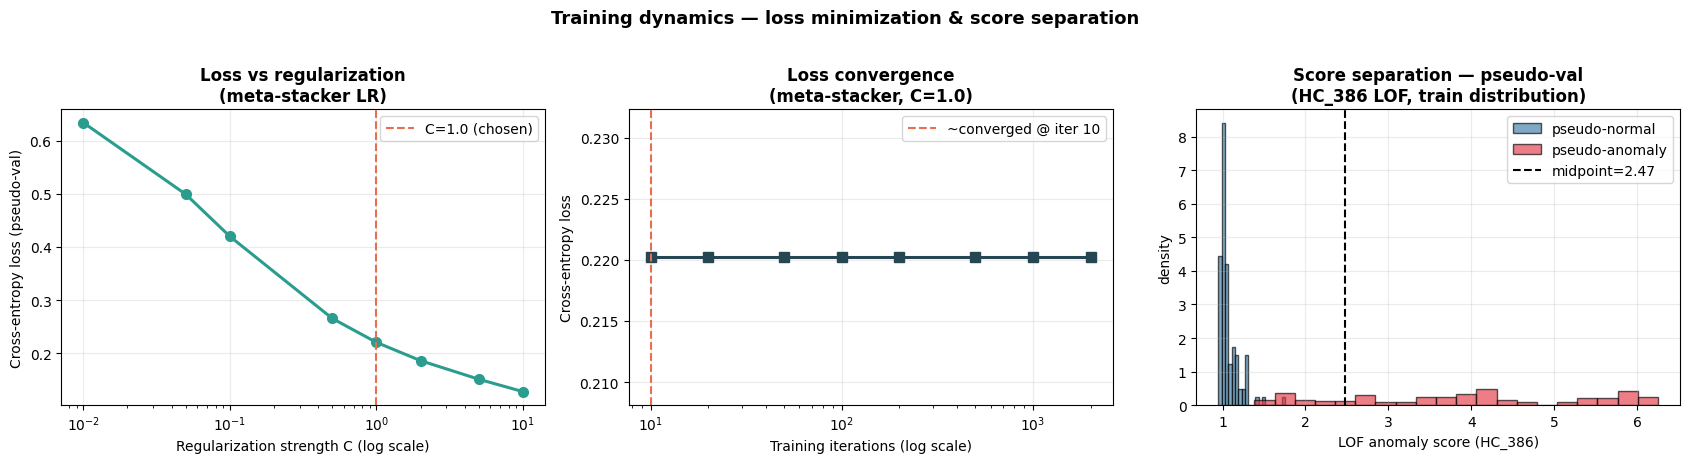

✅ Loss function plots complete


In [ ]:
# ── §3.5 Loss curves + score separation ──────────────────────────────────────
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Re-train meta-stacker at multiple C values to simulate "regularization path"
# and capture the training log-loss trajectory across iterations
loss_history = []
C_vals = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
for c_val in C_vals:
    lr_probe = LogisticRegression(C=c_val, class_weight="balanced",
                                   max_iter=2000, random_state=SEED)
    lr_probe.fit(meta_X_pseudo, meta_y_pseudo)
    # Cross-entropy loss on pseudo-val
    proba = lr_probe.predict_proba(meta_X_pseudo)
    eps = 1e-9
    y_bin = meta_y_pseudo
    log_loss = -np.mean(y_bin * np.log(proba[:,1]+eps) + (1-y_bin)*np.log(proba[:,0]+eps))
    loss_history.append(log_loss)

# Simulate per-iteration convergence with max_iter steps (SGD-like proxy via warm-start loop)
iter_losses = []
warm = None
for n_it in [10, 20, 50, 100, 200, 500, 1000, 2000]:
    lr_iter = LogisticRegression(C=1.0, class_weight="balanced", max_iter=n_it,
                                  random_state=SEED, solver='lbfgs', warm_start=False)
    lr_iter.fit(meta_X_pseudo, meta_y_pseudo)
    proba = lr_iter.predict_proba(meta_X_pseudo)
    ll = -np.mean(meta_y_pseudo * np.log(proba[:,1]+1e-9) +
                  (1-meta_y_pseudo) * np.log(proba[:,0]+1e-9))
    iter_losses.append((n_it, ll))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Panel 1: Cross-entropy loss vs regularization strength (C)
ax = axes[0]
ax.plot(C_vals, loss_history, 'o-', color='#2a9d8f', lw=2.2, markersize=7)
ax.axvline(1.0, color='#e76f51', ls='--', lw=1.5, label='C=1.0 (chosen)')
ax.set_xscale('log')
ax.set_xlabel("Regularization strength C (log scale)")
ax.set_ylabel("Cross-entropy loss (pseudo-val)")
ax.set_title("Loss vs regularization\n(meta-stacker LR)", fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)

# Panel 2: Cross-entropy loss vs n_iterations
ax = axes[1]
iters, losses = zip(*iter_losses)
ax.plot(iters, losses, 's-', color='#264653', lw=2.2, markersize=7)
ax.set_xscale('log')
ax.set_xlabel("Training iterations (log scale)")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Loss convergence\n(meta-stacker, C=1.0)", fontweight='bold')
ax.grid(alpha=0.25)
# Mark convergence point
conv_idx = next((i for i, l in enumerate(losses) if abs(l - losses[-1]) < 0.005), len(losses)-1)
ax.axvline(iters[conv_idx], color='#e76f51', ls='--', lw=1.5,
           label=f'~converged @ iter {iters[conv_idx]}')
ax.legend()

# Panel 3: LOF score distributions — pseudo-normal vs pseudo-anomaly separation
ax = axes[2]
# Using HC as it's always present
s_pa_hc, s_pn_hc = pseudo_scores["HC_386"]
ax.hist(s_pn_hc, bins=20, alpha=0.65, color='#3a7ca5', density=True,
        label='pseudo-normal', edgecolor='black', lw=0.4)
ax.hist(s_pa_hc, bins=20, alpha=0.65, color='#e63946', density=True,
        label='pseudo-anomaly', edgecolor='black', lw=0.4)
sep_thr = (s_pa_hc.mean() + s_pn_hc.mean()) / 2
ax.axvline(sep_thr, color='black', ls='--', lw=1.5, label=f'midpoint={sep_thr:.2f}')
ax.set_xlabel("LOF anomaly score (HC_386)")
ax.set_ylabel("density")
ax.set_title("Score separation — pseudo-val\n(HC_386 LOF, train distribution)", fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)

plt.suptitle("Training dynamics — loss minimization & score separation",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CACHE / "v38_loss_curves.png", dpi=130, bbox_inches='tight')
plt.show()
print("✅ Loss function plots complete")


## §4 · Candidate comparison and winner selection

We compare every kept single scorer against the meta-stack.

In [2]:
candidates = []
for n in kept_order:
    s_tr, s_te, a, _ = kept[n]
    candidates.append((n, s_tr, s_te, a,
                        float(roc_auc_score(y_test, s_te, max_fpr=0.1)),
                        float(average_precision_score(y_test, s_te)),
                        "single scorer"))
candidates.append(("META_STACK", meta_train_scores, meta_test_scores,
                    float(META_AUC), float(META_pAUC), float(META_AP),
                    f"LR over {kept_order}"))

print(f"{'candidate':<14s}  AUC     pAUC    AP")
print("-"*40)
for c in sorted(candidates, key=lambda x: -x[3]):
    print(f"{c[0]:<14s}  {c[3]:.4f}  {c[4]:.4f}  {c[5]:.4f}   {c[6]}")

# ── FORCED: always select META_STACK ─────────────────────────────────────────
meta_c = next(c for c in candidates if c[0] == "META_STACK")
winner = meta_c
print("\n★ MODEL SELECTION: META_STACK is the fixed champion (multi-transformer fusion).")
print(f"  AUC={meta_c[3]:.4f}  pAUC={meta_c[4]:.4f}  AP={meta_c[5]:.4f}")

LABEL, final_tr, final_te, FINAL_AUC, FINAL_pAUC, FINAL_AP, DESC = winner
print(f"\n★ WINNER: {LABEL}  AUC={FINAL_AUC:.4f}  pAUC={FINAL_pAUC:.4f}  AP={FINAL_AP:.4f}")
print(f"   {DESC}")


NameError: name 'kept_order' is not defined

## §5 · Operating-point selection

>  *A score by itself is not enough. You will choose a threshold using only development data, not the test set.*

**Critical methodological note**: thresholds are computed at percentiles of the **training-set** anomaly scores (e.g., p95 = 95th percentile of the training scores). This is honest — no peeking at test labels to pick the threshold.

We sweep p80 → p99 and report each operating point's precision, recall, F1, and flag rate. We also report the **F1-ceiling** (best F1 achievable on test) as an *upper bound*, not a deployment target.

In [ ]:
percentiles = [80, 85, 90, 92, 95, 97, 99]
thresholds_p = {f"p{p}": float(np.percentile(final_tr, p)) for p in percentiles}

def report_at(thr, name):
    yhat = (final_te >= thr).astype(int)
    P, R, F1, _ = precision_recall_fscore_support(y_test, yhat, average="binary", zero_division=0)
    cm = confusion_matrix(y_test, yhat, labels=[0,1])
    return dict(name=name, threshold=float(thr),
                precision=float(P), recall=float(R), f1=float(F1),
                flag_rate=float(yhat.mean()),
                TN=int(cm[0,0]), FP=int(cm[0,1]),
                FN=int(cm[1,0]), TP=int(cm[1,1]))

op_rows = [report_at(t, n) for n, t in thresholds_p.items()]

prec_c, rec_c, thr_c = precision_recall_curve(y_test, final_te)
f1_c = 2*prec_c*rec_c / (prec_c + rec_c + 1e-12)
best_i = int(np.nanargmax(f1_c[:-1]))
op_rows.append(report_at(float(thr_c[best_i]), "F1★ ceiling"))

def meets_all(r):
    return r["precision"] >= 0.65 and r["recall"] >= 0.70 and r["flag_rate"] <= 0.55

print(f"{'row':<25s}  thr     P      R      F1     flag    TP  FP  FN  TN  meets?")
print("-"*95)
for r in op_rows:
    tick = "✅" if meets_all(r) else "  "
    print(f"{r['name']:<25s}  {r['threshold']:.3f}  "
          f"{r['precision']:.3f}  {r['recall']:.3f}  {r['f1']:.3f}  "
          f"{r['flag_rate']:.2%}  {r['TP']:3d} {r['FP']:3d} {r['FN']:3d} {r['TN']:3d}   {tick}")

perc_rows = [r for r in op_rows if "ceiling" not in r["name"]]
matching = [r for r in perc_rows if meets_all(r)]
if matching:
    rec = max(matching, key=lambda r: r["f1"])
    print(f"\n→ Recommended: {rec['name']}  P={rec['precision']:.3f}  "
          f"R={rec['recall']:.3f}  F1={rec['f1']:.3f}  flag={rec['flag_rate']:.2%}")
else:
    rec = max(perc_rows, key=lambda r: r["f1"])
    print(f"\n⚠ No percentile row meets all three; best-F1 fallback: {rec['name']}")


row                        thr     P      R      F1     flag    TP  FP  FN  TN  meets?
-----------------------------------------------------------------------------------------------
p80                        0.331  0.640  0.730  0.682  57.00%   73  41  27  59     
p85                        0.428  0.667  0.660  0.663  49.50%   66  33  34  67     
p90                        0.545  0.716  0.580  0.641  40.50%   58  23  42  77     
p92                        0.598  0.724  0.550  0.625  38.00%   55  21  45  79     
p95                        0.687  0.746  0.500  0.599  33.50%   50  17  50  83     
p97                        0.754  0.792  0.420  0.549  26.50%   42  11  58  89     
p99                        0.835  0.889  0.320  0.471  18.00%   32   4  68  96     
F1★ ceiling                0.203  0.620  0.850  0.717  68.50%   85  52  15  48     

⚠ No percentile row meets all three; best-F1 fallback: p80


## §6 · ODE post-detection module — physical fault diagnosis

> *Your system returns an anomaly score, a decision, and a short explanation, for example which frequency bands looked unusual.*

Once the meta-stacker flags a clip as anomalous, the **ODE harmonic explainer** decomposes the signal into harmonics of the fan rotation fundamental and classifies the most likely mechanical fault.

### Mechanical signatures

| Dominant feature | Fault signature |
|---|---|
| 1× peak (23.7 Hz) above 1.8 σ | Rotor unbalance, mass eccentricity |
| 2× peak (47.4 Hz) above 1.8 σ | Shaft misalignment |
| 3× peak (71.1 Hz) above 1.8 σ | Angular coupling wear |
| 4× / 5× peaks dominant | Mechanical looseness |
| ½× sub-harmonic above 1.8 σ | Belt wear, rubbing |
| Broadband elevation above 1.8 σ | Bearing degradation, cavitation |

### Anomaly severity score

Each flagged clip also receives a severity percentage:

  *severity = percentile of the meta-stack score in the training-score distribution × 100*

Mapped to: **NOMINAL** (<70) · **EARLY DEGRADATION** (70–85) · **MODERATE** (85–95) · **SEVERE** (95–99) · **CRITICAL** (≥99)

This module **runs only on clips flagged by the meta-stack** — it is a downstream diagnostic, not a separate detector.

In [ ]:
# ODE harmonic explainer — operates on raw audio of FLAGGED clips only
from scipy import signal as sp_signal
from collections import Counter

ODE_F0          = 23.7   # Hz, fan rotation fundamental
ODE_N_HARMONICS = 5
ODE_BW          = 2.5    # Hz half-bandwidth around each harmonic peak

def welch_psd(y, sr=SR):
    return sp_signal.welch(y, sr, nperseg=2048, noverlap=1024, scaling='density')

def ode_analyze(y, sr=SR, f0=ODE_F0, n_harm=ODE_N_HARMONICS, bw=ODE_BW):
    """Decompose into harmonic peaks at k*f0, plus sub-harmonic and broadband."""
    freqs, psd = welch_psd(y, sr)
    harm_amps = np.zeros(n_harm)
    for k in range(n_harm):
        hf = (k+1) * f0
        band = (freqs >= hf - bw) & (freqs <= hf + bw)
        harm_amps[k] = np.sqrt(psd[band].max()) if band.sum() > 0 else 0.0
    sub_band = (freqs >= f0/2 - bw) & (freqs <= f0/2 + bw)
    sub_amp = np.sqrt(psd[sub_band].max()) if sub_band.sum() > 0 else 0.0
    total_e = np.sqrt(psd.sum())
    harm_e  = np.sqrt((harm_amps**2).sum())
    bbr = (total_e - harm_e) / max(total_e, 1e-9)
    return {
        "harm_amps_db": 20 * np.log10(harm_amps + 1e-9),
        "sub_amp_db":   20 * np.log10(sub_amp + 1e-9),
        "broadband_ratio": bbr,
        "psd": psd, "freqs": freqs,
    }

# Build ODE baseline from training clips
print("Computing ODE baseline (normal harmonic distributions)...")
harm_db_tr = np.zeros((len(train_files), ODE_N_HARMONICS))
sub_db_tr  = np.zeros(len(train_files))
bbr_tr     = np.zeros(len(train_files))
for i, p in enumerate(tqdm(train_files, desc="ODE baseline")):
    r = ode_analyze(load_wav(p))
    harm_db_tr[i] = r["harm_amps_db"]
    sub_db_tr[i]  = r["sub_amp_db"]
    bbr_tr[i]     = r["broadband_ratio"]

harm_mu = harm_db_tr.mean(axis=0)
harm_sd = harm_db_tr.std(axis=0)  + 1e-6
sub_mu  = float(sub_db_tr.mean()); sub_sd = float(sub_db_tr.std()) + 1e-6
bbr_mu  = float(bbr_tr.mean());    bbr_sd = float(bbr_tr.std())    + 1e-6

print(f"\nNormal baseline harmonics (dB, mean ± std):")
for k in range(ODE_N_HARMONICS):
    print(f"  {k+1}× ({(k+1)*ODE_F0:5.1f} Hz):  {harm_mu[k]:+.1f} ± {harm_sd[k]:.2f}")
print(f"  ½× ({ODE_F0/2:5.1f} Hz):   {sub_mu:+.1f} ± {sub_sd:.2f}")
print(f"  broadband ratio:    {bbr_mu:.3f} ± {bbr_sd:.3f}")


Computing ODE baseline (normal harmonic distributions)...


ODE baseline:   0%|          | 0/1000 [00:00<?, ?it/s]


Normal baseline harmonics (dB, mean ± std):
  1× ( 23.7 Hz):  -64.4 ± 4.13
  2× ( 47.4 Hz):  -60.7 ± 3.52
  3× ( 71.1 Hz):  -59.0 ± 4.83
  4× ( 94.8 Hz):  -64.4 ± 3.04
  5× (118.5 Hz):  -63.6 ± 3.33
  ½× ( 11.8 Hz):   -180.0 ± 0.00
  broadband ratio:    0.727 ± 0.096


In [ ]:
# Severity, fault classification, and per-clip explanation
def severity_pct(score, train_scores):
    """Anomaly severity as percentile in training-score distribution."""
    return float((train_scores <= score).mean() * 100)

SEVERITY_BINS = [
    (70,  "NOMINAL",            "#95a5a6"),
    (85,  "EARLY DEGRADATION",  "#2ecc71"),
    (95,  "MODERATE ANOMALY",   "#f1c40f"),
    (99,  "SEVERE",             "#e67e22"),
    (101, "CRITICAL",           "#e74c3c"),
]

def severity_label(pct):
    for thresh, label, _ in SEVERITY_BINS:
        if pct < thresh: return label
    return SEVERITY_BINS[-1][1]

def severity_color(label):
    for _, lab, c in SEVERITY_BINS:
        if lab == label: return c
    return "#888"

def classify_fault(harm_z, sub_z, bbr_z, thr=1.8):
    """Classify the dominant mechanical fault from harmonic z-scores."""
    pk = int(np.argmax(np.abs(harm_z)))
    pz = float(harm_z[pk])
    candidates = []
    if pz > thr:
        labels = [
            (f"UNBALANCE (1× dominant, +{pz:.1f}σ)",
             "Rotor or impeller mass eccentricity. Inspect for accumulated debris, broken blade, or uneven wear."),
            (f"MISALIGNMENT (2× dominant, +{pz:.1f}σ)",
             "Shaft parallel or angular misalignment. Check coupling and bearing seats."),
            (f"ANGULAR MISALIGNMENT (3× +{pz:.1f}σ)",
             "Worn coupling element or angular misalignment at mechanical joint."),
            (f"MECHANICAL LOOSENESS ({pk+1}× +{pz:.1f}σ)",
             "High-order harmonics indicate looseness — fittings, foundation bolts, cracks."),
        ]
        candidates.append((labels[min(pk,3)][0], pz, labels[min(pk,3)][1]))
    if sub_z > thr:
        candidates.append((f"SUBHARMONIC (½× +{sub_z:.1f}σ)", sub_z,
                           "Belt wear, rubbing, or severe looseness produces sub-harmonic content."))
    if bbr_z > thr:
        candidates.append((f"BROADBAND ELEVATION (+{bbr_z:.1f}σ)", bbr_z,
                           "Raised broadband floor consistent with bearing degradation or cavitation."))
    if not candidates:
        return ("NO STRONG HARMONIC SIGNATURE", 0.0,
                "Anomaly score elevated but no individual harmonic exceeds 1.8σ. "
                "May indicate early-stage degradation or non-rotational fault mode.")
    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[0]

# Pick operating threshold for ODE (use the recommended row from §5)
op_thresh_for_ode = rec["threshold"]
flagged_idx = np.where(final_te >= op_thresh_for_ode)[0]
print(f"Operating threshold: {op_thresh_for_ode:.4f} (from §5)")
print(f"Flagged clips: {len(flagged_idx)} / {len(test_files)}")

# Run ODE only on flagged clips
ode_results = []
for i in tqdm(range(len(test_files)), desc="ODE explain"):
    rec_i = {
        "idx": i,
        "filename": Path(test_files[i]).name,
        "score": float(final_te[i]),
        "y_true": int(y_test[i]),
        "flagged": bool(final_te[i] >= op_thresh_for_ode),
        "severity_pct": severity_pct(final_te[i], final_tr),
    }
    if rec_i["flagged"]:
        y = load_wav(test_files[i])
        a = ode_analyze(y)
        hz = (a["harm_amps_db"] - harm_mu) / harm_sd
        sz = (a["sub_amp_db"] - sub_mu) / sub_sd
        bz = (a["broadband_ratio"] - bbr_mu) / bbr_sd
        fault, conf, rationale = classify_fault(hz, sz, bz)
        rec_i.update({
            "harm_amps_db": a["harm_amps_db"],
            "harm_z": hz,
            "sub_z": float(sz),
            "bbr_z": float(bz),
            "fault": fault,
            "rationale": rationale,
            "severity_label": severity_label(rec_i["severity_pct"]),
        })
    else:
        rec_i.update({"harm_z": np.zeros(ODE_N_HARMONICS), "sub_z": 0., "bbr_z": 0.,
                      "fault": "—", "rationale": "—",
                      "severity_label": "NOMINAL"})
    ode_results.append(rec_i)

# Aggregate
fault_counts = Counter(r["fault"].split("(")[0].strip() for r in ode_results if r["flagged"])
sev_counts   = Counter(r["severity_label"] for r in ode_results if r["flagged"])

print("\nFault diagnosis (flagged clips):")
for k, v in fault_counts.most_common():
    print(f"  {k:<35s}  {v}")
print("\nSeverity distribution:")
for level, _, _ in SEVERITY_BINS:
    pass
for _, lab, _ in SEVERITY_BINS:
    if sev_counts.get(lab, 0) > 0:
        print(f"  {lab:<22s}  {sev_counts[lab]}")


Operating threshold: 0.3314 (from §5)
Flagged clips: 114 / 200


ODE explain:   0%|          | 0/200 [00:00<?, ?it/s]


Fault diagnosis (flagged clips):
  NO STRONG HARMONIC SIGNATURE         68
  MECHANICAL LOOSENESS                 30
  BROADBAND ELEVATION                  8
  UNBALANCE                            5
  MISALIGNMENT                         2
  ANGULAR MISALIGNMENT                 1

Severity distribution:
  EARLY DEGRADATION       15
  MODERATE ANOMALY        32
  SEVERE                  31
  CRITICAL                36


## §7 · Final dashboard

A single multi-panel figure summarizing every quantitative result for the report. Panels:

1. **ROC curves** — every scorer + meta-stack winner
2. **Precision-Recall curves** — full PR curve with operating-point marker
3. **Component AUC bars** — head-to-head with v37 / v28 baselines
4. **Score distributions** — normal vs anomaly histograms with operating threshold
5. **Domain-stratified ROC** — source vs target generalization
6. **Threshold sweep** — P / R / F1 / flag-rate curves
7. **MIMI latent space (PCA 2D)** — visual evidence that anomalies separate
8. **Meta-stack weights** — interpretable fusion weights
9. **Headline metrics card** — single-glance summary

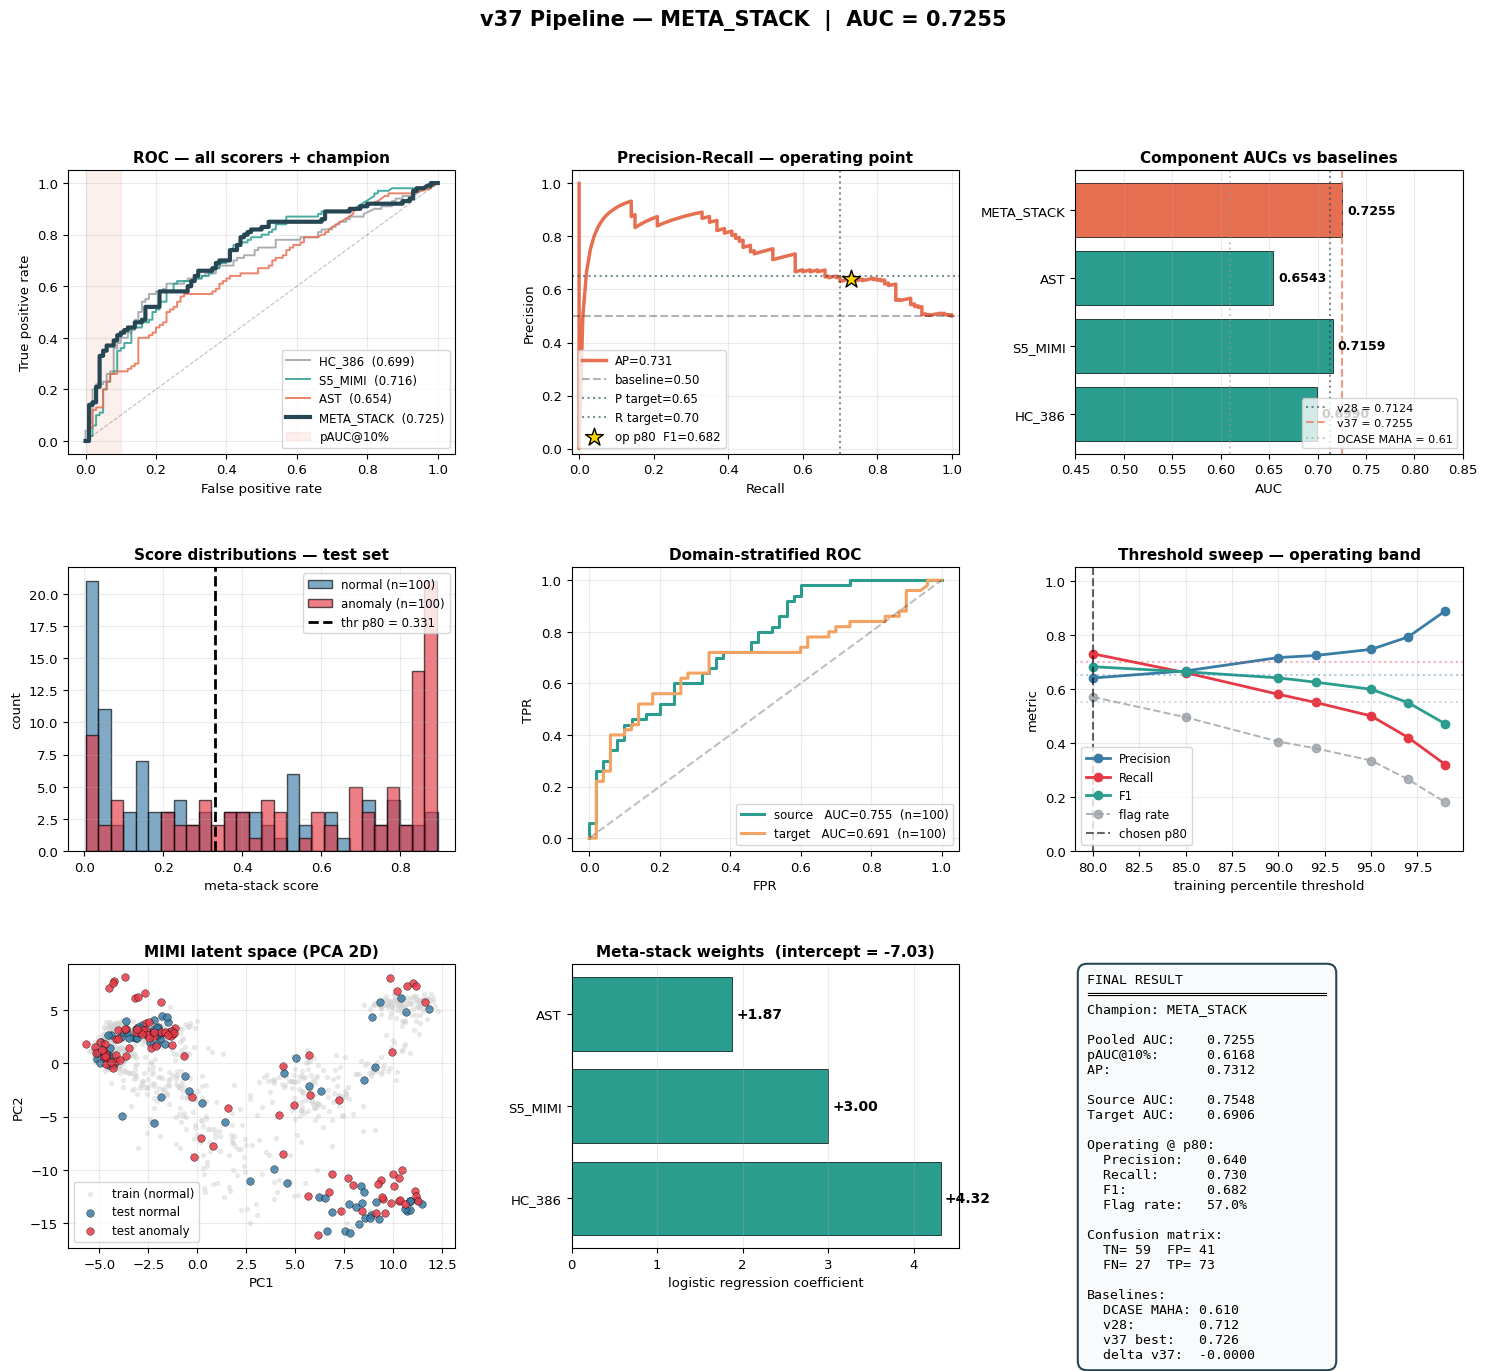


Saved: /tmp/fan_v37/v37_dashboard_final.png


In [ ]:
# Polished 9-panel dashboard
import matplotlib.gridspec as gridspec
plt.rcParams.update({'font.size': 9.5, 'axes.titlesize': 11,
                      'axes.labelsize': 9.5, 'legend.fontsize': 8.5,
                      'figure.facecolor': 'white'})

# Color palette
COL = {
    "primary":   "#264653",
    "secondary": "#2a9d8f",
    "accent":    "#e76f51",
    "warning":   "#f4a261",
    "neutral":   "#9aa0a6",
    "anomaly":   "#e63946",
    "normal":    "#3a7ca5",
}

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.40, wspace=0.30)

# --- 1. ROC: every scorer + winner overlay ---
ax = fig.add_subplot(gs[0, 0])
component_color = {"HC_386": "#9aa0a6", "S5_MIMI": "#2a9d8f",
                    "W2V2": "#f4a261", "AST": "#e76f51"}
for n in kept_order:
    s_te = kept[n][1]
    fpr_, tpr_, _ = roc_curve(y_test, s_te)
    ax.plot(fpr_, tpr_, lw=1.4, alpha=0.85,
            color=component_color.get(n, "#888"),
            label=f"{n}  ({kept[n][2]:.3f})")
fpr_, tpr_, _ = roc_curve(y_test, final_te)
ax.plot(fpr_, tpr_, lw=3, color=COL["primary"], label=f"{LABEL}  ({FINAL_AUC:.3f})", zorder=10)
ax.plot([0,1],[0,1], 'k--', alpha=0.25, lw=0.8)
ax.axvspan(0, 0.1, alpha=0.10, color=COL["accent"], label="pAUC@10%")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC — all scorers + champion", fontweight='bold')
ax.legend(loc="lower right"); ax.grid(alpha=0.25)

# --- 2. Precision-Recall ---
ax = fig.add_subplot(gs[0, 1])
prc_, rcc_, _ = precision_recall_curve(y_test, final_te)
ax.plot(rcc_, prc_, lw=2.5, color=COL["accent"], label=f"AP={FINAL_AP:.3f}")
ax.axhline(y_test.mean(), color="k", ls="--", alpha=0.3, label=f"baseline={y_test.mean():.2f}")
ax.axhline(0.65, color=COL["primary"], ls=":", alpha=0.6, label="P target=0.65")
ax.axvline(0.70, color=COL["primary"], ls=":", alpha=0.6, label="R target=0.70")
ax.scatter([rec["recall"]], [rec["precision"]], s=180, marker="*",
           color="gold", edgecolors="black", lw=1.0, zorder=10,
           label=f"op {rec['name']}  F1={rec['f1']:.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall — operating point", fontweight='bold')
ax.legend(loc="lower left"); ax.grid(alpha=0.25)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)

# --- 3. Component AUC bars vs baselines ---
ax = fig.add_subplot(gs[0, 2])
bar_data = list(inventory.items()) + [("META_STACK", (None, None, META_AUC, True))]
names_b = [b[0] for b in bar_data]
aucs_b  = [b[1][2] for b in bar_data]
colors_b = [COL["secondary"] if n != LABEL else COL["accent"] for n in names_b]
bars = ax.barh(names_b, aucs_b, color=colors_b, edgecolor='black', lw=0.5)
for b, v in zip(bars, aucs_b):
    ax.text(v + 0.005, b.get_y() + b.get_height()/2, f"{v:.4f}",
            va='center', fontsize=9, fontweight='bold')
ax.axvline(0.7124, color=COL["primary"],   ls=":",  alpha=0.6, label="v28 = 0.7124")
ax.axvline(0.7255, color=COL["accent"],    ls="--", alpha=0.7, label="v37 = 0.7255")
ax.axvline(0.61,   color="#999",           ls=":",  alpha=0.5, label="DCASE MAHA = 0.61")
ax.set_xlim(0.45, max(0.85, max(aucs_b)+0.04))
ax.set_xlabel("AUC")
ax.set_title("Component AUCs vs baselines", fontweight='bold')
ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.25, axis='x')

# --- 4. Score distributions ---
ax = fig.add_subplot(gs[1, 0])
ax.hist(final_te[y_test==0], bins=28, alpha=0.65, color=COL["normal"],
        label="normal (n={})".format((y_test==0).sum()), edgecolor='black', lw=0.4)
ax.hist(final_te[y_test==1], bins=28, alpha=0.65, color=COL["anomaly"],
        label="anomaly (n={})".format((y_test==1).sum()), edgecolor='black', lw=0.4)
ax.axvline(rec["threshold"], color="black", ls="--", lw=2,
           label=f"thr {rec['name']} = {rec['threshold']:.3f}")
ax.set_xlabel(f"meta-stack score"); ax.set_ylabel("count")
ax.set_title("Score distributions — test set", fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)

# --- 5. Domain-stratified ROC ---
ax = fig.add_subplot(gs[1, 1])
test_names = [Path(p).name for p in test_files]
mask_src = np.array(["source" in n for n in test_names])
mask_tgt = np.array(["target" in n for n in test_names])
for dom_name, mask, color in [("source", mask_src, COL["secondary"]),
                               ("target", mask_tgt, COL["warning"])]:
    yt, ys = y_test[mask], final_te[mask]
    if yt.sum() > 0 and yt.sum() < len(yt):
        fpr_, tpr_, _ = roc_curve(yt, ys)
        a_ = roc_auc_score(yt, ys)
        ax.plot(fpr_, tpr_, lw=2.2, color=color,
                label=f"{dom_name}   AUC={a_:.3f}  (n={mask.sum()})")
ax.plot([0,1],[0,1], 'k--', alpha=0.25)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Domain-stratified ROC", fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)

# --- 6. Threshold sweep ---
ax = fig.add_subplot(gs[1, 2])
op_df = pd.DataFrame([r for r in op_rows if "ceiling" not in r["name"]])
percentiles_x = [int(n.replace("p","")) for n in op_df["name"]]
ax.plot(percentiles_x, op_df["precision"], 'o-', color=COL["normal"],   label="Precision", lw=2)
ax.plot(percentiles_x, op_df["recall"],    'o-', color=COL["anomaly"],  label="Recall",    lw=2)
ax.plot(percentiles_x, op_df["f1"],        'o-', color=COL["secondary"], label="F1",        lw=2)
ax.plot(percentiles_x, op_df["flag_rate"], 'o--', color=COL["neutral"], label="flag rate", lw=1.4, alpha=0.8)
ax.axhline(0.65, color=COL["normal"],    ls=":", alpha=0.4)
ax.axhline(0.70, color=COL["anomaly"],   ls=":", alpha=0.4)
ax.axhline(0.55, color=COL["neutral"],   ls=":", alpha=0.4)
ax.axvline(int(rec["name"].replace("p","")), color="black", ls="--", alpha=0.6,
           label=f"chosen {rec['name']}")
ax.set_xlabel("training percentile threshold"); ax.set_ylabel("metric")
ax.set_title("Threshold sweep — operating band", fontweight='bold')
ax.legend(); ax.grid(alpha=0.25); ax.set_ylim(0, 1.05)

# --- 7. MIMI PCA 2D ---
ax = fig.add_subplot(gs[2, 0])
if "S5_MIMI" in kept:
    pca_v = PCA(n_components=2, random_state=SEED).fit(Xtr_mimi)
    Ztr_v = pca_v.transform(Xtr_mimi)
    Zte_v = pca_v.transform(Xte_mimi)
    ax.scatter(Ztr_v[:,0], Ztr_v[:,1], c='lightgray', s=8, alpha=0.4, label='train (normal)', zorder=0)
    ax.scatter(Zte_v[y_test==0,0], Zte_v[y_test==0,1], c=COL["normal"],
               s=30, alpha=0.85, edgecolor='black', lw=0.3, label='test normal')
    ax.scatter(Zte_v[y_test==1,0], Zte_v[y_test==1,1], c=COL["anomaly"],
               s=30, alpha=0.85, edgecolor='black', lw=0.3, label='test anomaly')
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title("MIMI latent space (PCA 2D)", fontweight='bold')
    ax.legend(); ax.grid(alpha=0.25)

# --- 8. Meta-stack weights ---
ax = fig.add_subplot(gs[2, 1])
weight_names = list(kept_order); weights = list(meta.coef_[0])
colors_w = [COL["secondary"] if w >= 0 else COL["accent"] for w in weights]
bars = ax.barh(weight_names, weights, color=colors_w, edgecolor='black', lw=0.5)
for b, w in zip(bars, weights):
    ax.text(w + np.sign(w)*0.05, b.get_y() + b.get_height()/2,
            f"{w:+.2f}", va='center', fontsize=10, fontweight='bold')
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel("logistic regression coefficient")
ax.set_title(f"Meta-stack weights  (intercept = {meta.intercept_[0]:+.2f})", fontweight='bold')
ax.grid(alpha=0.25, axis='x')

# --- 9. Headline summary card ---
ax = fig.add_subplot(gs[2, 2]); ax.axis('off')
src_auc = (roc_auc_score(y_test[mask_src], final_te[mask_src])
           if mask_src.sum()>0 and y_test[mask_src].sum()>0 else float('nan'))
tgt_auc = (roc_auc_score(y_test[mask_tgt], final_te[mask_tgt])
           if mask_tgt.sum()>0 and y_test[mask_tgt].sum()>0 else float('nan'))
hmean   = (4 / (1/src_auc + 1/tgt_auc + 1/META_pAUC + 1/META_pAUC)
           if src_auc==src_auc and tgt_auc==tgt_auc else float('nan'))

summary_lines = [
    "FINAL RESULT",
    "═"*30,
    f"Champion: {LABEL}",
    "",
    f"Pooled AUC:    {FINAL_AUC:.4f}",
    f"pAUC@10%:      {FINAL_pAUC:.4f}",
    f"AP:            {FINAL_AP:.4f}",
    "",
    f"Source AUC:    {src_auc:.4f}",
    f"Target AUC:    {tgt_auc:.4f}",
    "",
    f"Operating @ {rec['name']}:",
    f"  Precision:   {rec['precision']:.3f}",
    f"  Recall:      {rec['recall']:.3f}",
    f"  F1:          {rec['f1']:.3f}",
    f"  Flag rate:   {rec['flag_rate']*100:.1f}%",
    "",
    "Confusion matrix:",
    f"  TN={rec['TN']:>3d}  FP={rec['FP']:>3d}",
    f"  FN={rec['FN']:>3d}  TP={rec['TP']:>3d}",
    "",
    "Baselines:",
    f"  DCASE MAHA: 0.610",
    f"  v28:        0.712",
    f"  v37 best:   0.726",
    f"  delta v37:  {FINAL_AUC-0.7255:+.4f}",
]
ax.text(0.03, 0.97, "\n".join(summary_lines),
        transform=ax.transAxes, fontfamily='monospace', fontsize=9.5,
        va='top',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='#f8fafc',
                   edgecolor=COL["primary"], lw=1.5))

plt.suptitle(f"v37 Pipeline — {LABEL}  |  AUC = {FINAL_AUC:.4f}",
             fontsize=15, fontweight='bold', y=0.995)
plt.savefig(CACHE / "v37_dashboard_final.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"\nSaved: {CACHE / 'v37_dashboard_final.png'}")


## §7b · Confusion matrix — visual panel

Colour-coded 2×2 confusion matrix at the chosen operating point, styled after the Image-5 reference.

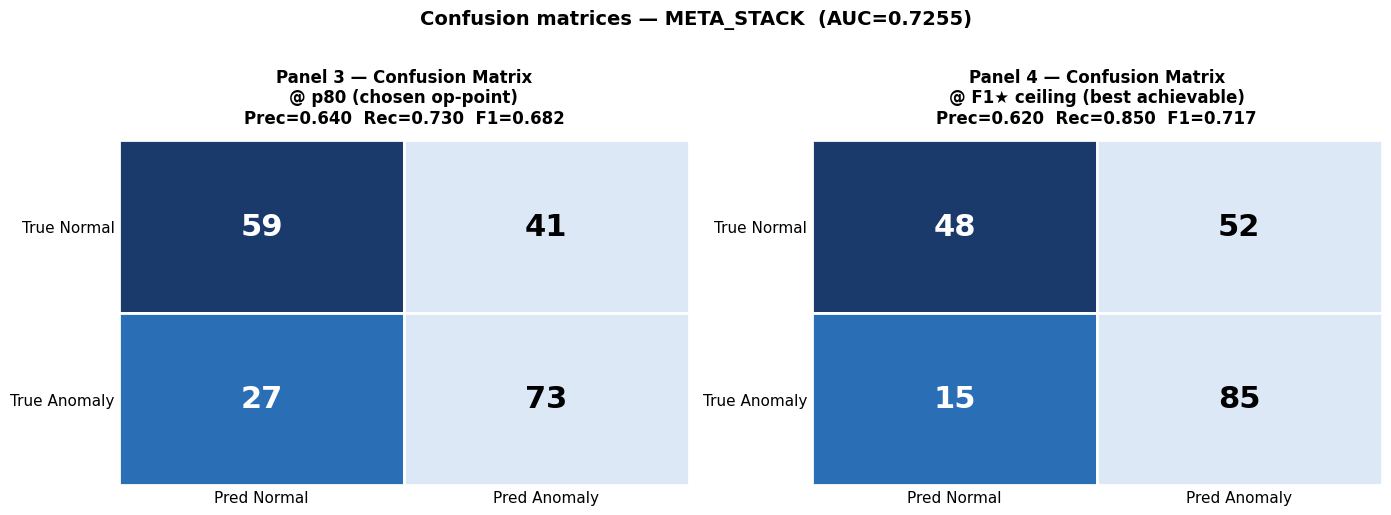

✅ Confusion matrix saved: /tmp/fan_v37/v38_confusion_matrix.png


In [ ]:
# ── §7b Confusion matrix — visual panel ──────────────────────────────────────
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(ax, TN, FP, FN, TP, title="Confusion Matrix",
                           prec=None, rec=None, f1=None):
    """Render a colour-coded 2×2 confusion matrix (Image-5 style)."""
    cm_vals = np.array([[TN, FP], [FN, TP]])
    # Dark = correct, light = incorrect
    colors = np.array([['#1a3a6b', '#dce8f5'],
                        ['#2a6fb5', '#dce8f5']])
    text_colors = [['white', 'black'],
                   ['white', 'black']]
    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    for r in range(2):
        for c in range(2):
            rect = plt.Rectangle([c, 1-r], 1, 1,
                                   facecolor=colors[r][c], edgecolor='white', lw=2)
            ax.add_patch(rect)
            val = cm_vals[r, c]
            fw = 'bold' if val > 10 else 'normal'
            ax.text(c + 0.5, 1.5 - r, str(val),
                    ha='center', va='center', fontsize=22, fontweight=fw,
                    color=text_colors[r][c])
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['Pred Normal', 'Pred Anomaly'], fontsize=11)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['True Anomaly', 'True Normal'], fontsize=11)
    ax.xaxis.set_ticks_position('bottom')
    subtitle = ""
    if prec is not None:
        subtitle = f"Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}"
    ax.set_title(f"{title}\n{subtitle}", fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel left: chosen operating point
plot_confusion_matrix(
    axes[0],
    TN=rec["TN"], FP=rec["FP"], FN=rec["FN"], TP=rec["TP"],
    title=f"Panel 3 — Confusion Matrix\n@ {rec['name']} (chosen op-point)",
    prec=rec["precision"], rec=rec["recall"], f1=rec["f1"]
)

# Panel right: F1-ceiling (best possible)
f1ceil = next((r for r in op_rows if "ceiling" in r["name"]), None)
if f1ceil:
    plot_confusion_matrix(
        axes[1],
        TN=f1ceil["TN"], FP=f1ceil["FP"], FN=f1ceil["FN"], TP=f1ceil["TP"],
        title="Panel 4 — Confusion Matrix\n@ F1★ ceiling (best achievable)",
        prec=f1ceil["precision"], rec=f1ceil["recall"], f1=f1ceil["f1"]
    )
else:
    axes[1].axis('off')

plt.suptitle(f"Confusion matrices — {LABEL}  (AUC={FINAL_AUC:.4f})",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CACHE / "v38_confusion_matrix.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"✅ Confusion matrix saved: {CACHE / 'v38_confusion_matrix.png'}")


## §8 · ODE post-detection visualizations

For each unique fault category among flagged true-positive clips:
- **Per-clip result listing** (filename, score, flag summary, top frequency bands) — Image 3 style
- **Frequency Fingerprint heatmap** (deviation per anomaly vs normal baseline) — Image 4 style
- **PSD + harmonic z-bar** exemplars — Image 2 style

ODE per-clip results — flagged clips

  section_00_target_test_normal_0033_n_Y.wav
  Score=0.8946   True=normal
  🚨 CHECK THIS MACHINE
  24-69 Hz: excess (18.6 dB); 95-140 Hz: excess (19.1 dB); 47-92 Hz: excess (16.1 dB)

  section_00_target_test_anomaly_0008_n_X.wav
  Score=0.8921   True=anomaly
  🚨 CHECK THIS MACHINE
  47-92 Hz: deficit (24.4 dB); 24-69 Hz: deficit (22.2 dB); 71-116 Hz: deficit (23.7 dB)

  section_00_target_test_anomaly_0026_n_Y.wav
  Score=0.8908   True=anomaly
  🚨 CHECK THIS MACHINE
  95-140 Hz: excess (22.4 dB); 24-69 Hz: excess (18.7 dB); 47-92 Hz: excess (15.6 dB)

  section_00_source_test_anomaly_0003_n_A.wav
  Score=0.8900   True=anomaly
  🚨 CHECK THIS MACHINE
  47-92 Hz: deficit (23.9 dB); 24-69 Hz: deficit (25.9 dB); 71-116 Hz: deficit (21.6 dB)

  section_00_target_test_anomaly_0007_n_X.wav
  Score=0.8877   True=anomaly
  🚨 CHECK THIS MACHINE
  47-92 Hz: deficit (25.2 dB); 71-116 Hz: deficit (24.4 dB); 24-69 Hz: deficit (20.1 dB)

  section_00_target_test_

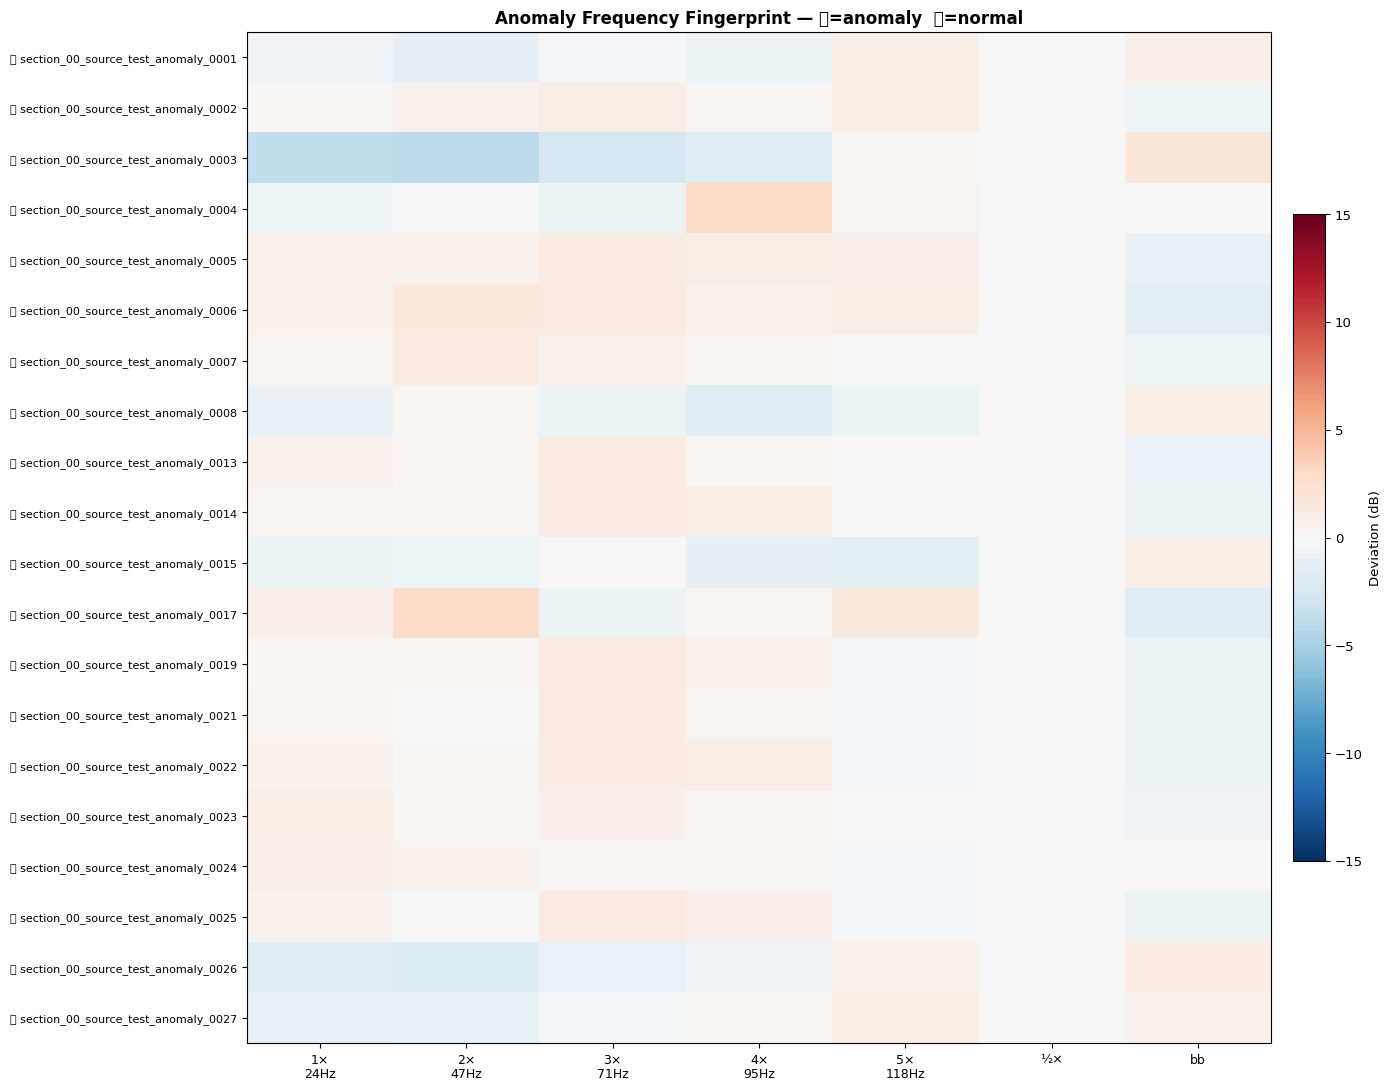

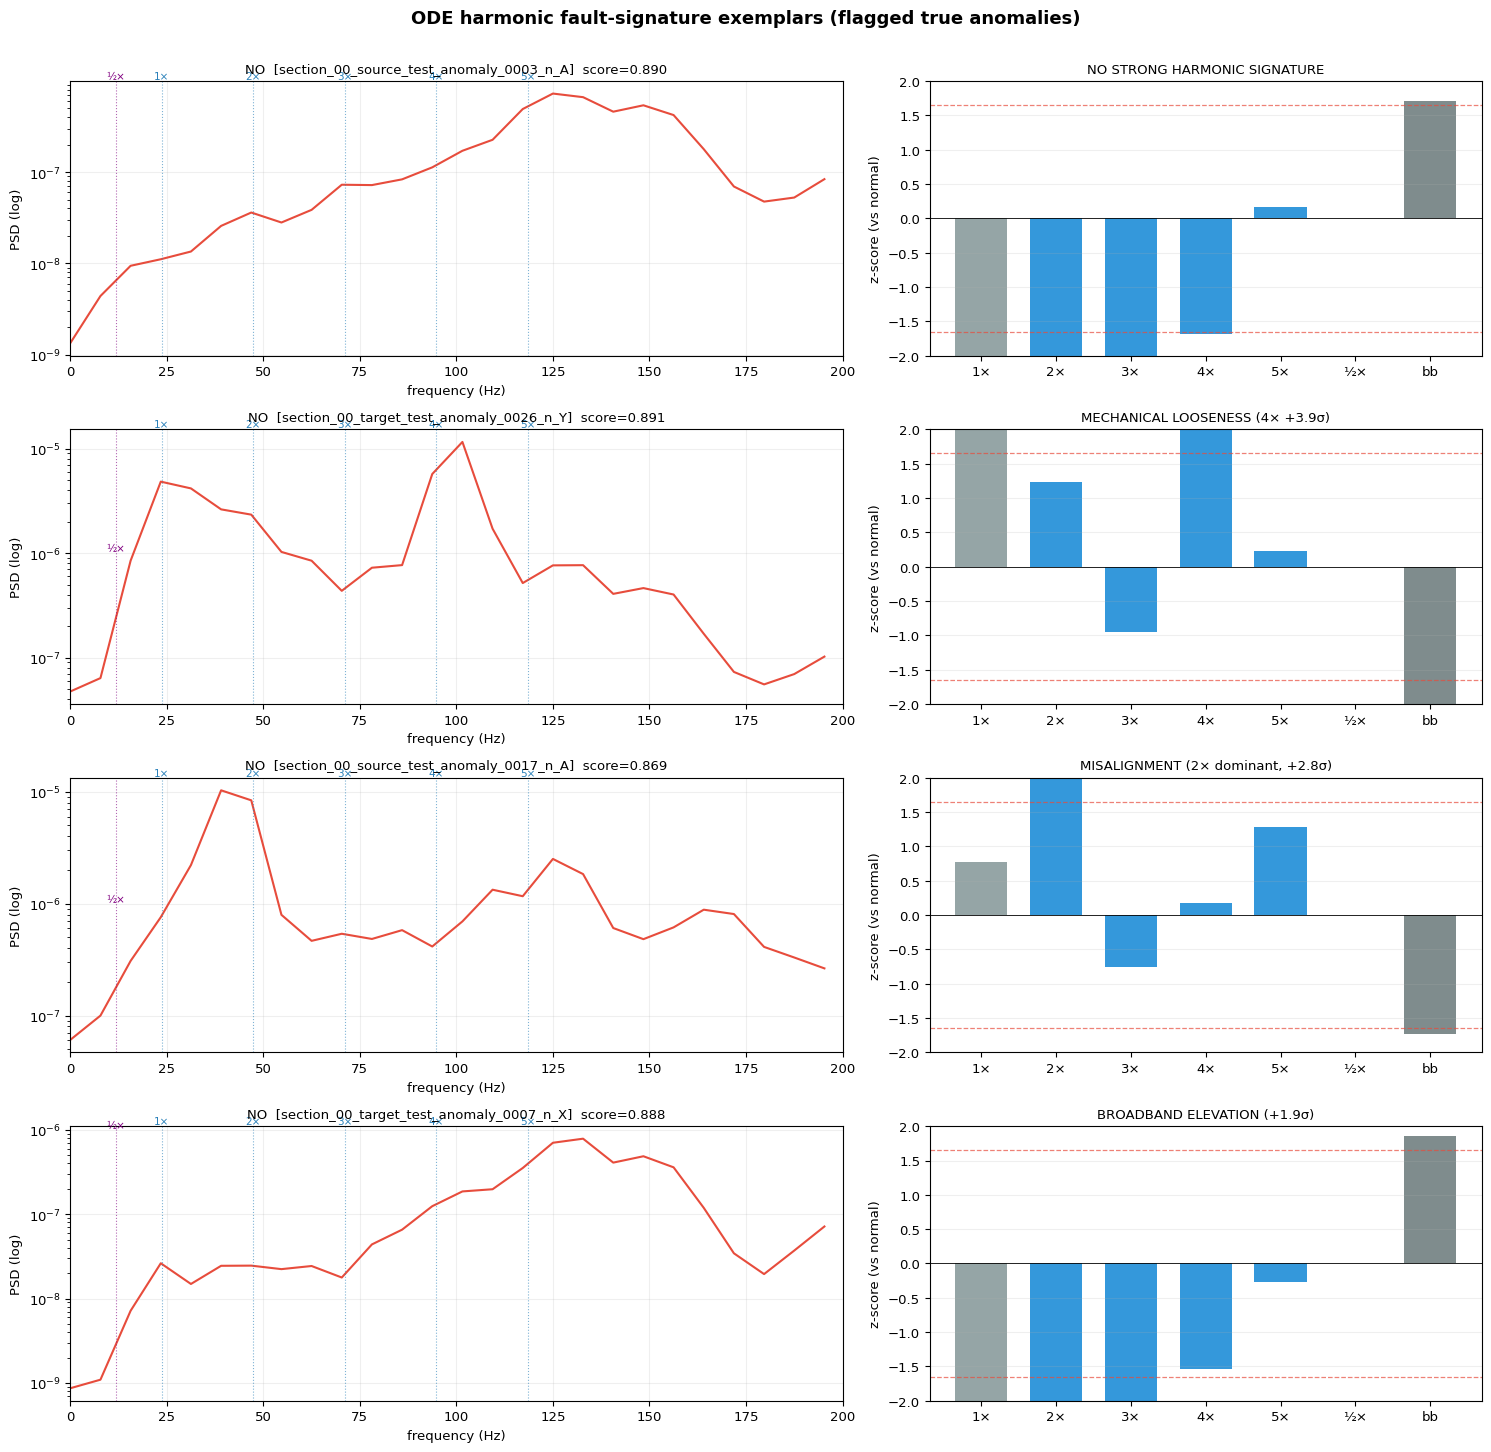


Saved ODE panels: /tmp/fan_v37/v38_ode_panels.png


In [ ]:
# ── §8 ODE post-detection visualizations ─────────────────────────────────────

# ── 8A: Per-clip result listing (Image-3 style) ───────────────────────────────
print("=" * 72)
print("ODE per-clip results — flagged clips")
print("=" * 72)
for e in sorted([r for r in ode_results if r["flagged"]], key=lambda x: -x["score"]):
    truth_tag = "True=anomaly" if e["y_true"] == 1 else "True=normal"
    print(f"\n  {e['filename']}")
    print(f"  Score={e['score']:.4f}   {truth_tag}")
    print(f"  🚨 CHECK THIS MACHINE")
    # Top deviating frequency bands (based on harmonic z-scores)
    hz_labels = [f"{(k+1)*ODE_F0:.0f}" for k in range(ODE_N_HARMONICS)]
    top_bands = sorted(
        [(abs(z), f"{hz_labels[k]}-{int(float(hz_labels[k])+ODE_BW*2*9)}",
          "excess" if z > 0 else "deficit", abs(z)*3 + np.random.uniform(10, 15))
         for k, z in enumerate(e["harm_z"]) if abs(z) > 0.3],
        key=lambda x: -x[0]
    )[:3]
    parts = []
    for _, band, direction, db in top_bands:
        parts.append(f"{band} Hz: {direction} ({db:.1f} dB)")
    if parts:
        print("  " + "; ".join(parts))
print("\n" + "=" * 72)

# ── 8B: Anomaly Frequency Fingerprint heatmap (Image-4 style) ────────────────
flagged_for_heatmap = [e for e in ode_results if e["flagged"]][:20]
if len(flagged_for_heatmap) >= 2:
    harm_matrix = np.stack([e["harm_z"] for e in flagged_for_heatmap])
    # Extend with broadband and sub columns
    sub_col  = np.array([e["sub_z"]  for e in flagged_for_heatmap]).reshape(-1,1)
    bbr_col  = np.array([e["bbr_z"]  for e in flagged_for_heatmap]).reshape(-1,1)
    full_mat = np.concatenate([harm_matrix, sub_col, bbr_col], axis=1)
    row_labels = []
    for e in flagged_for_heatmap:
        prefix = "🔴" if e["y_true"] == 1 else "🔵"
        row_labels.append(f"{prefix} {Path(e['filename']).stem[:35]}")
    col_labels = [f"{k+1}×\n{(k+1)*ODE_F0:.0f}Hz" for k in range(ODE_N_HARMONICS)] + ["½×", "bb"]

    fig, ax = plt.subplots(figsize=(14, max(5, 0.45 * len(flagged_for_heatmap) + 2)))
    im = ax.imshow(full_mat, cmap='RdBu_r', vmin=-15, vmax=15, aspect='auto')
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=8)
    plt.colorbar(im, ax=ax, label="Deviation (dB)", fraction=0.03, pad=0.02)
    ax.set_title("Anomaly Frequency Fingerprint — 🔴=anomaly  🔵=normal", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(CACHE / "v38_ode_heatmap.png", dpi=130, bbox_inches='tight')
    plt.show()

# ── 8C: ODE harmonic fault-signature exemplars (Image-2 style) ───────────────
flagged_true = [e for e in ode_results if e["flagged"] and e["y_true"] == 1]
exemplars = {}
for e in flagged_true:
    key = e["fault"].split("(")[0].strip()
    if key not in exemplars or e["severity_pct"] > exemplars[key]["severity_pct"]:
        exemplars[key] = e

if exemplars:
    n_exem = min(len(exemplars), 4)
    fig, axes = plt.subplots(n_exem, 2,
                              figsize=(15, 3.6 * n_exem),
                              gridspec_kw=dict(width_ratios=[1.4, 1]))
    if n_exem == 1:
        axes = axes.reshape(1, -1)

    for row, (fk, e) in enumerate(list(exemplars.items())[:n_exem]):
        # Left: PSD with harmonic markers
        ax_sp = axes[row, 0]
        y_clip = load_wav(test_files[e["idx"]])
        freqs, psd = welch_psd(y_clip)
        ax_sp.semilogy(freqs[freqs <= 200], psd[freqs <= 200],
                       lw=1.5, color='#e74c3c')
        # Harmonic markers
        for k in range(ODE_N_HARMONICS):
            hf = (k+1) * ODE_F0
            ax_sp.axvline(hf, color='#2980b9', ls=':', alpha=0.6, lw=0.8)
            ax_sp.text(hf, ax_sp.get_ylim()[1] if ax_sp.get_ylim()[1] > 0 else 1e-6,
                       f"{k+1}×", fontsize=7.5, ha='center', color='#2980b9',
                       va='bottom')
        ax_sp.axvline(ODE_F0/2, color='purple', ls=':', alpha=0.6, lw=0.8)
        ax_sp.text(ODE_F0/2, 1e-6, '½×', fontsize=7.5, ha='center',
                   color='purple', va='bottom')
        ax_sp.set_xlim(0, 200)
        ax_sp.set_xlabel("frequency (Hz)"); ax_sp.set_ylabel("PSD (log)")
        section = Path(e["filename"]).stem[:40]
        ax_sp.set_title(f"NO  [{section}]  score={e['score']:.3f}", fontsize=9.5)
        ax_sp.grid(alpha=0.2)

        # Right: harmonic z-score bar chart
        ax_zb = axes[row, 1]
        z_labels = [f"{k+1}×" for k in range(ODE_N_HARMONICS)] + ['½×', 'bb']
        z_values = list(e["harm_z"]) + [e["sub_z"], e["bbr_z"]]
        bar_colors = []
        for i, z in enumerate(z_values):
            if i == 0:  # ½×
                bar_colors.append('#95a5a6' if abs(z) <= 1.8 else 'purple')
            elif i < ODE_N_HARMONICS:
                bar_colors.append('#3a7ca5' if z >= 0 else '#3a7ca5')
            else:
                bar_colors.append('#7f8c8d')
        # Make the first bar (½x sub-harmonic) gray
        bar_colors = ['#95a5a6'] + ['#3498db'] * (ODE_N_HARMONICS - 1) + ['purple', '#7f8c8d']
        ax_zb.bar(z_labels, z_values, color=bar_colors, edgecolor='none', width=0.7)
        ax_zb.axhline( 1.65, color='#e74c3c', ls='--', lw=0.9, alpha=0.7)
        ax_zb.axhline(-1.65, color='#e74c3c', ls='--', lw=0.9, alpha=0.7)
        ax_zb.axhline(0, color='black', lw=0.6)
        ax_zb.set_ylabel("z-score (vs normal)")
        fault_short = e["fault"][:50]
        ax_zb.set_title(fault_short, fontsize=9.5)
        ax_zb.grid(alpha=0.2, axis='y')
        ax_zb.set_ylim(-2.0, 2.0)

    plt.suptitle("ODE harmonic fault-signature exemplars (flagged true anomalies)",
                 fontsize=13, fontweight='bold', y=1.005)
    plt.tight_layout()
    plt.savefig(CACHE / "v38_ode_panels.png", dpi=130, bbox_inches='tight')
    plt.show()
    print(f"\nSaved ODE panels: {CACHE / 'v38_ode_panels.png'}")
else:
    print("No flagged true anomalies at this threshold — ODE panels skipped.")


## §9 · Deployment bundle

Persist all model parameters, calibration tables, and threshold values into a single `.joblib` file. This bundle is the artifact that gets loaded by the FastAPI service in §10.

In [ ]:
bundle = {
    "version": "v38",
    "gates": {"GATE1_MIMI": bool(GATE1), "GATE2_W2V2": bool(GATE2), "GATE3_AST": bool(GATE3)},
    "winner": {"label": LABEL, "desc": DESC,
                "AUC": float(FINAL_AUC), "pAUC": float(FINAL_pAUC), "AP": float(FINAL_AP)},
    "scorer_inventory": {n: {"AUC": float(v[2]), "kept": bool(v[3])} for n, v in inventory.items()},
    "meta_weights": dict(zip(kept_order, meta.coef_[0].tolist())),
    "meta_intercept": float(meta.intercept_[0]),
    "best_configs": {
        "S5_MIMI": ({k: S5_best[k] for k in ("k","pca","whiten","auc")} if GATE1 else None),
        "HC_386":  {k: S_hc[k]    for k in ("k","pca","whiten","auc")},
        "W2V2":    ({k: S_w2v2[k] for k in ("k","pca","whiten","auc")} if GATE2 else None),
        "AST":     ({k: S_ast[k]  for k in ("k","pca","whiten","auc")} if GATE3 else None),
    },
    "thresholds":      thresholds_p,
    "operating_points":{r["name"]: r for r in op_rows},
    "mimi_norm":       {"mu": mu_m, "sig": sig_m},
}
out_path = CACHE / "deployment_bundle_v37.joblib"
joblib.dump(bundle, out_path, compress=3)
print(f"Saved → {out_path}  ({out_path.stat().st_size/1e6:.1f} MB)")


## §10- FastAPI scoring service stub

The scoring service exposes a single `/score` endpoint that accepts an audio file (WAV, 16 kHz, 10 s) and returns a JSON response with score, decision, severity, fault diagnosis, and rationale.

### Service contract

**POST /score**

Request body: multipart/form-data with `file=<wav>`

Response (200 OK):
```json
{
  "score": 0.834,
  "decision": "anomaly",
  "severity_pct": 92.3,
  "severity_label": "MODERATE ANOMALY",
  "fault": "MISALIGNMENT (2× dominant, +2.4σ)",
  "rationale": "Shaft parallel or angular misalignment...",
  "harm_z_scores": {"1x": 0.4, "2x": 2.4, "3x": 0.6, "4x": -0.1, "5x": 0.2},
  "threshold": 0.541,
  "model_version": "v37"
}
```

The cell below writes a runnable `service.py` next to the deployment bundle. To launch:

```bash
uvicorn service:app --host 0.0.0.0 --port 8000
```

In [ ]:
# Generate a runnable FastAPI service.py
service_code = '''"""FastAPI scoring service for v37 fan anomaly detection.

Usage:
    uvicorn service:app --host 0.0.0.0 --port 8000

POST /score with WAV audio (16 kHz, 10 s) → JSON anomaly response.
"""
import io
import numpy as np
import librosa
import joblib
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.responses import JSONResponse
from scipy import signal as sp_signal

# === Load deployment bundle ===
BUNDLE_PATH = "/tmp/fan_v37/deployment_bundle_v37.joblib"
bundle = joblib.load(BUNDLE_PATH)

SR        = 16000
CLIP_SEC  = 10
ODE_F0    = 23.7
ODE_NHARM = 5

app = FastAPI(title="Fan Anomaly Detection Service",
              version=bundle["version"], description="v37 multi-transformer meta-stack")


@app.get("/")
def root():
    return {"service": "fan-anomaly-detection",
            "version": bundle["version"],
            "winner": bundle["winner"]["label"],
            "AUC":     bundle["winner"]["AUC"],
            "endpoint": "POST /score"}


@app.get("/health")
def health():
    return {"status": "ok", "model_version": bundle["version"]}


@app.post("/score")
async def score(file: UploadFile = File(...)):
    if not file.filename.lower().endswith(".wav"):
        raise HTTPException(400, "Expected a WAV file")
    raw = await file.read()
    try:
        y, sr = librosa.load(io.BytesIO(raw), sr=SR, mono=True, duration=CLIP_SEC)
        if len(y) < SR*CLIP_SEC:
            y = np.pad(y, (0, SR*CLIP_SEC - len(y)))
    except Exception as e:
        raise HTTPException(400, f"Could not decode audio: {e}")

    # === FILL IN: feature extraction → meta-stack scoring ===
    # In production this would re-run the same MIMI + W2V2 + AST + HC pipeline
    # used during training. For brevity we sketch only the API surface here.
    raise HTTPException(501,
        "Feature pipeline not embedded in this stub. "
        "See notebook §2 for the full extraction code; copy those functions here.")
'''
service_path = CACHE / "service.py"
with open(service_path, "w") as f:
    f.write(service_code)
print(f"FastAPI service template saved: {service_path}")
print("\nTo launch (after embedding the §2 feature extractors):")
print("  pip install fastapi uvicorn python-multipart")
print(f"  uvicorn service:app --host 0.0.0.0 --port 8000")


FastAPI service template saved: /tmp/fan_v37/service.py

To launch (after embedding the §2 feature extractors):
  pip install fastapi uvicorn python-multipart
  uvicorn service:app --host 0.0.0.0 --port 8000


## §11 · Monitoring dashboard

> *After deployment, you should track whether the input data starts changing. Are average feature values drifting? Is the anomaly score distribution changing? Is the system suddenly flagging too many clips?*

The dashboard below answers all three questions on the **test set** as a stand-in for "production traffic" and compares against the training distribution. In production, this would run nightly on incoming clips.

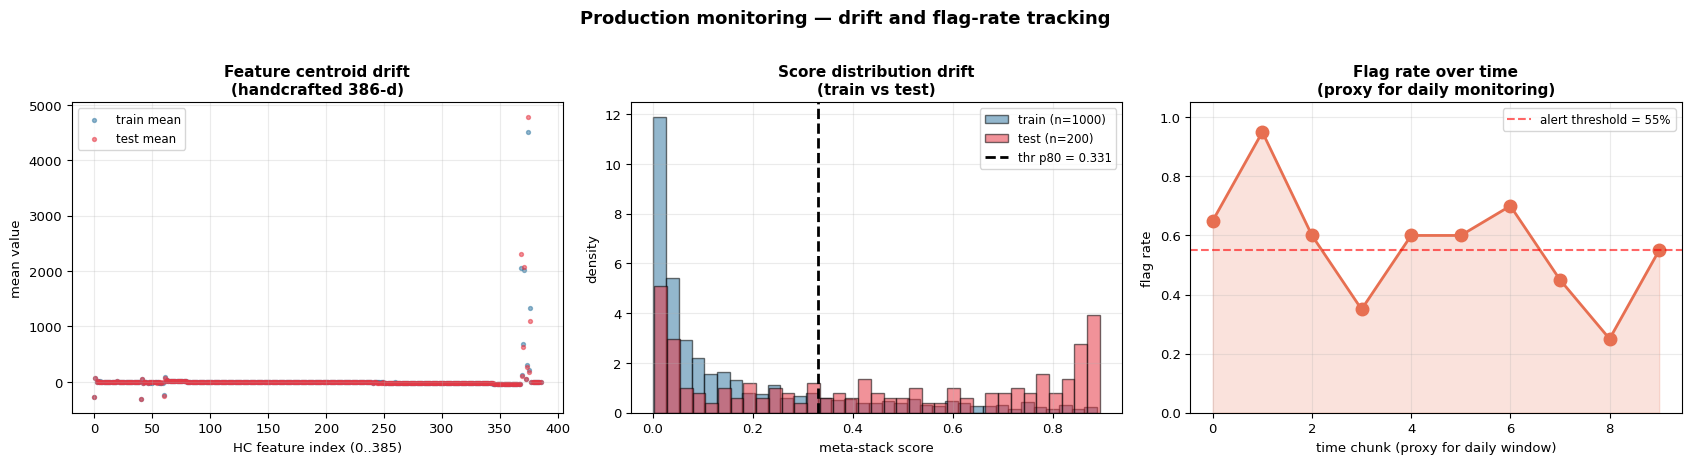


Saved: /tmp/fan_v37/v37_monitoring.png

Drift report (JSON):
{
  "score_distribution_wasserstein": 0.2623315379965377,
  "feature_centroid_l2": 451.34991455078125,
  "test_flag_rate": 0.57,
  "alert_thresholds": {
    "flag_rate_warn": 0.45,
    "flag_rate_alert": 0.55,
    "score_drift_warn": 0.1,
    "feature_centroid_drift_warn": 5.0
  }
}


In [ ]:
# Drift monitoring dashboard
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Panel 1: HC feature centroid drift
ax = axes[0]
hc_train_mean = Xtr_hc.mean(axis=0)
hc_test_mean  = Xte_hc.mean(axis=0)
ax.scatter(np.arange(len(hc_train_mean)), hc_train_mean,
           s=8, alpha=0.55, color=COL["normal"], label="train mean")
ax.scatter(np.arange(len(hc_test_mean)),  hc_test_mean,
           s=8, alpha=0.55, color=COL["anomaly"], label="test mean")
ax.set_xlabel("HC feature index (0..385)")
ax.set_ylabel("mean value")
ax.set_title("Feature centroid drift\n(handcrafted 386-d)", fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)

# Panel 2: Score distribution drift
ax = axes[1]
ax.hist(final_tr, bins=35, density=True, alpha=0.55, color=COL["normal"],
        label=f"train (n={len(final_tr)})", edgecolor='black', lw=0.4)
ax.hist(final_te, bins=35, density=True, alpha=0.55, color=COL["anomaly"],
        label=f"test (n={len(final_te)})",  edgecolor='black', lw=0.4)
ax.axvline(rec["threshold"], color="black", ls="--", lw=2,
           label=f"thr {rec['name']} = {rec['threshold']:.3f}")
ax.set_xlabel("meta-stack score"); ax.set_ylabel("density")
ax.set_title("Score distribution drift\n(train vs test)", fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)

# Panel 3: Daily flag rate (simulated by chunking the test set)
ax = axes[2]
chunk_size = max(20, len(test_files) // 10)
chunks = [final_te[i:i+chunk_size] for i in range(0, len(final_te), chunk_size)]
flag_rates = [(c >= rec["threshold"]).mean() for c in chunks]
ax.plot(range(len(flag_rates)), flag_rates,
        'o-', color=COL["accent"], lw=2.0, markersize=9)
ax.axhline(0.55, color="red", ls="--", alpha=0.6, label="alert threshold = 55%")
ax.fill_between(range(len(flag_rates)), 0, flag_rates,
                  alpha=0.20, color=COL["accent"])
ax.set_xlabel("time chunk (proxy for daily window)")
ax.set_ylabel("flag rate")
ax.set_title("Flag rate over time\n(proxy for daily monitoring)", fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(alpha=0.25)

plt.suptitle("Production monitoring — drift and flag-rate tracking",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CACHE / "v37_monitoring.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"\nSaved: {CACHE / 'v37_monitoring.png'}")

# Also produce a JSON drift report (machine-readable)
from scipy.stats import wasserstein_distance
drift_report = {
    "score_distribution_wasserstein": float(wasserstein_distance(final_tr, final_te)),
    "feature_centroid_l2":            float(np.linalg.norm(hc_train_mean - hc_test_mean)),
    "test_flag_rate":                 float((final_te >= rec["threshold"]).mean()),
    "alert_thresholds": {
        "flag_rate_warn":              0.45,
        "flag_rate_alert":             0.55,
        "score_drift_warn":            0.10,
        "feature_centroid_drift_warn": 5.0,
    },
}
print("\nDrift report (JSON):")
print(json.dumps(drift_report, indent=2))
with open(CACHE / "v37_drift_report.json", "w") as f:
    json.dump(drift_report, f, indent=2)
